### IMPORTING LIBRARIES

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor  
from sklearn.model_selection import train_test_split  
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  

### LOAD DATASET

In [10]:
# LOAD THE DATASET (WITH ISO-8859-1 ENCODING)
df_new_data = pd.read_csv("../DATA/DATA.csv",  encoding='ISO-8859-1')

### TEMPERATURE PREDICTION PREPROCESSING AND VISUALIZATION

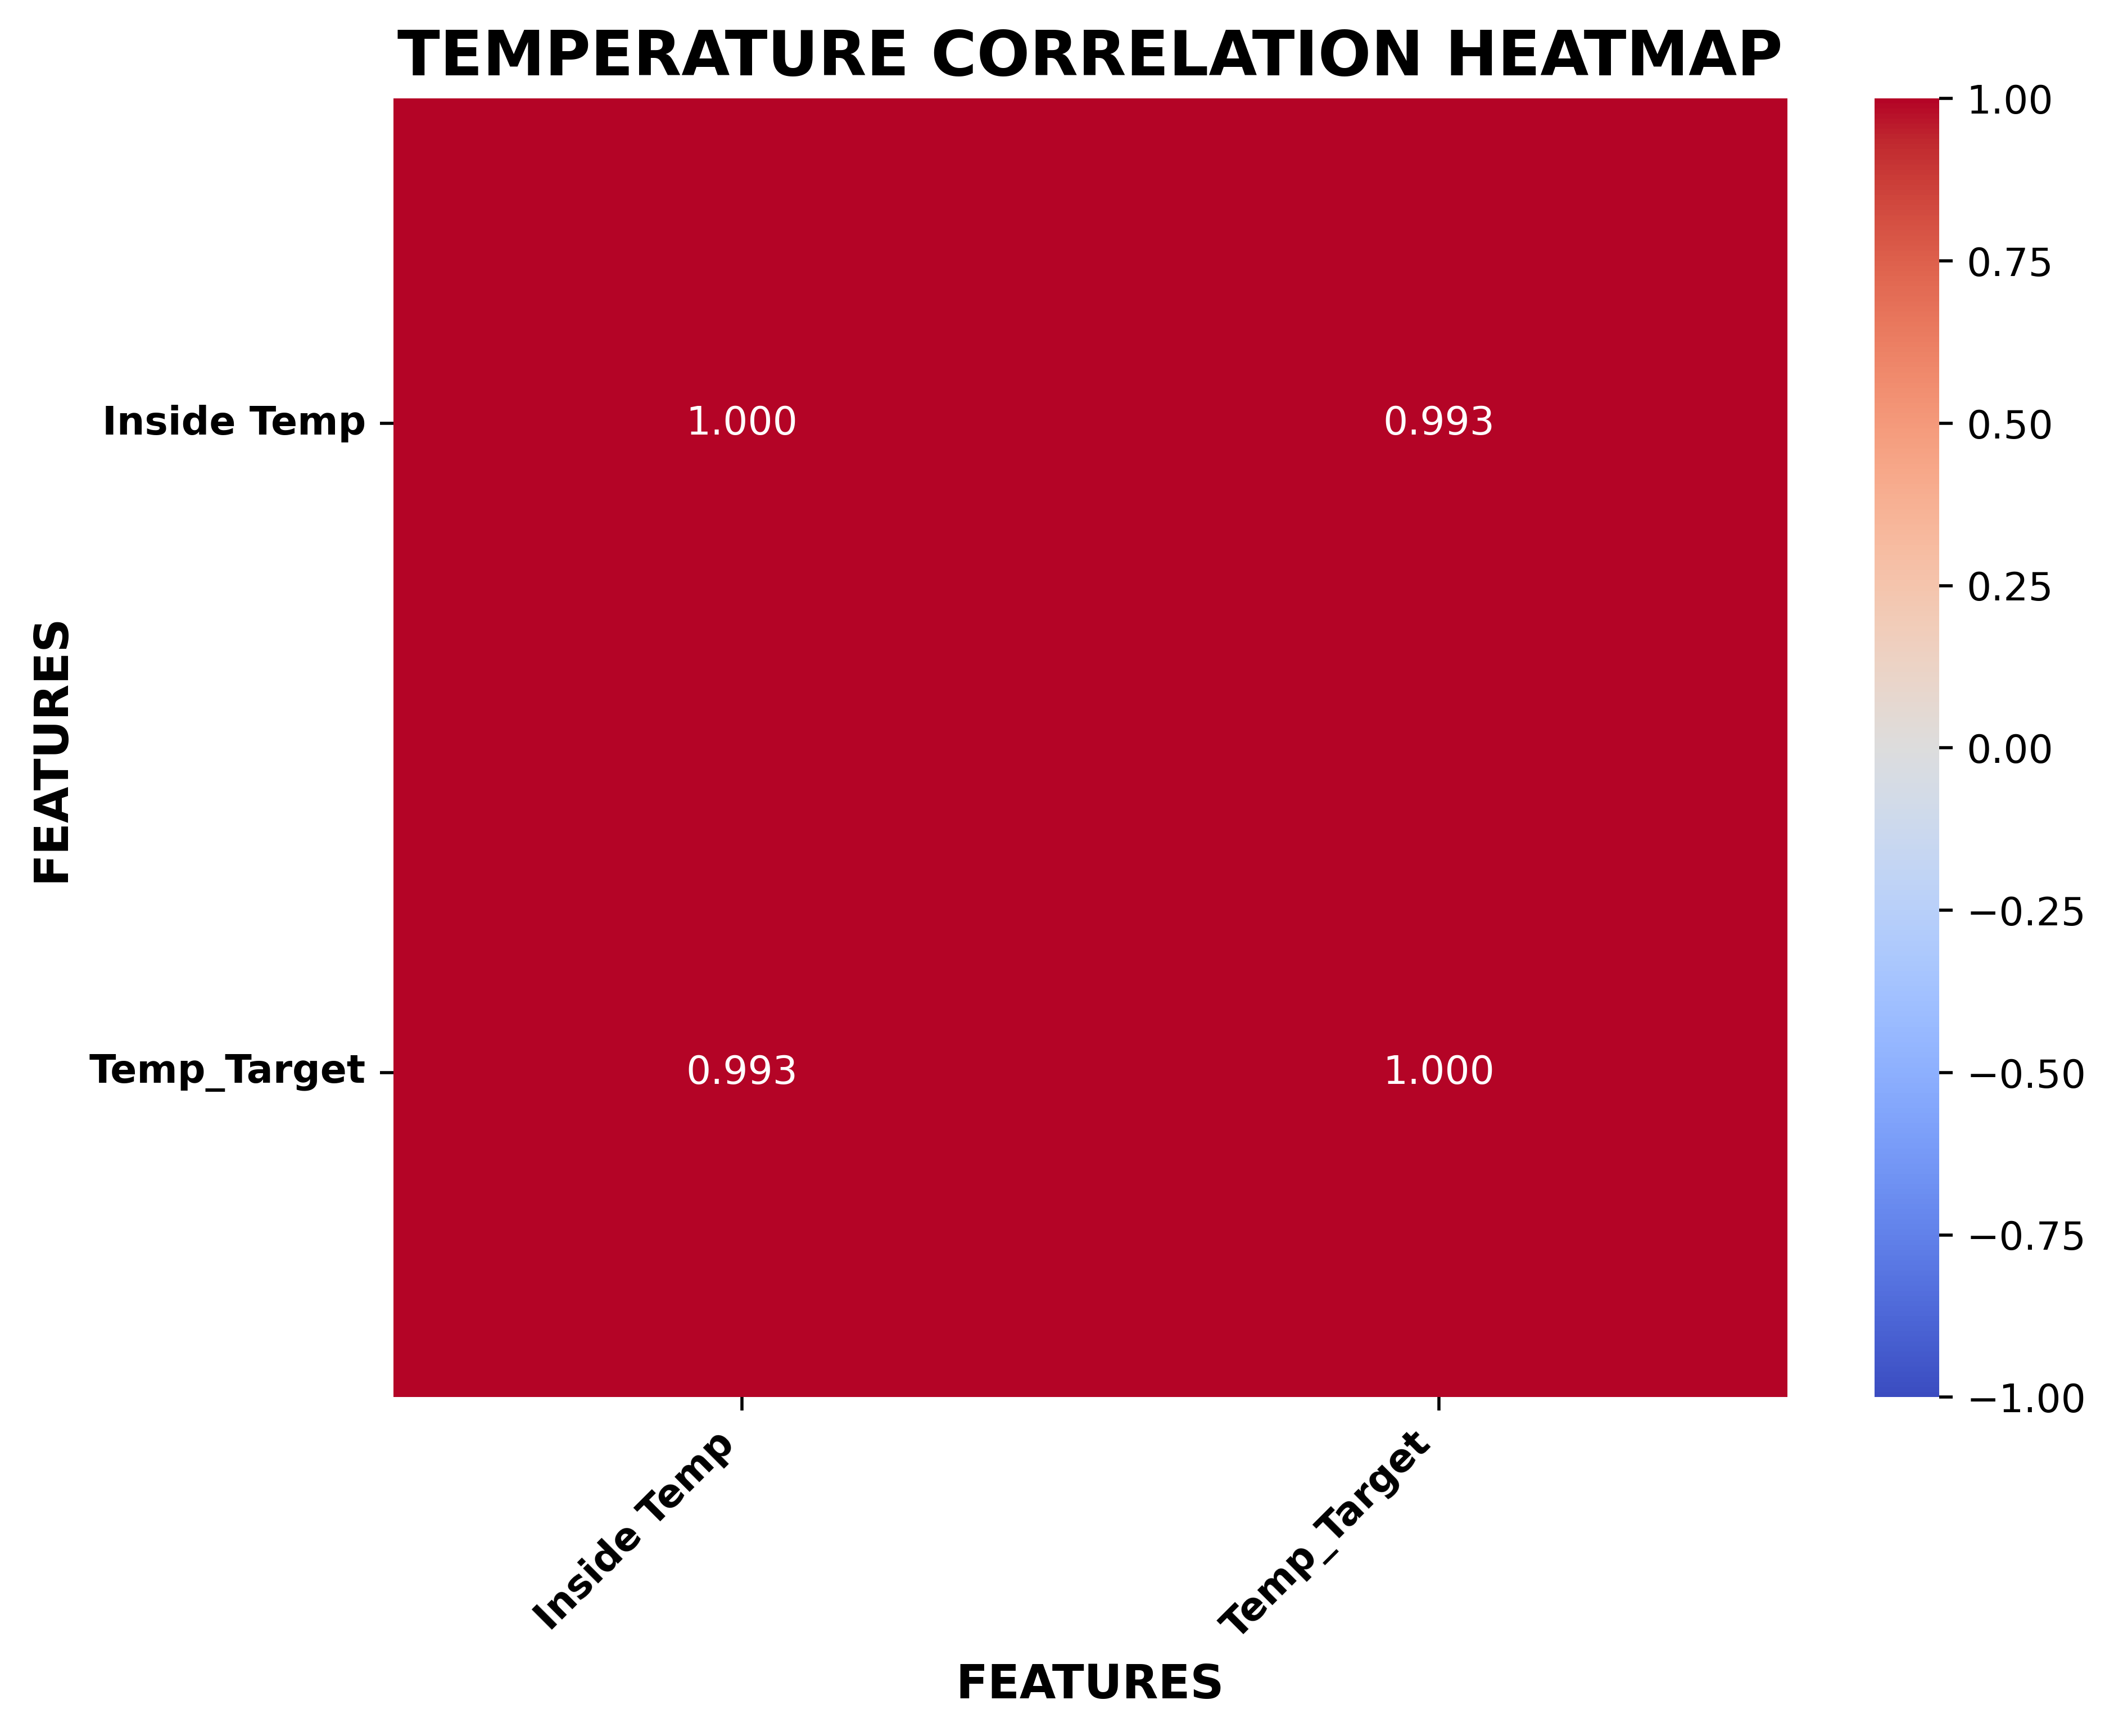

PREPARED DATASET FOR TEMPERATURE PREDICTION (df_temp):
         date.time  Inside Temp  Temp_Target
0  2/24/2024 10:45         23.9         24.7
1  2/24/2024 10:50         24.2         24.9
2  2/24/2024 10:55         24.4         25.1
3  2/24/2024 11:00         24.7         25.3
4  2/24/2024 11:05         24.9         25.4


In [20]:
# STRIP WHITESPACE FROM COLUMN NAMES
df_conti.columns = df_conti.columns.str.strip()  # REMOVE EXTRA WHITESPACE FROM COLUMN NAMES

# REPLACE '--' WITH 0 IN THE DATASET
df_clean = df_new_data.replace('--', 0)  # REPLACE INVALID '--' VALUES WITH 0

# DROP NON-NUMERIC COLUMNS (TO KEEP ONLY RELEVANT FEATURES) BUT KEEP 'date.time'
df_conti = df_clean.drop(columns=['Prevailing Wind Direction', 'High Wind Direction'])  # KEEP 'date.time' FOR FINAL DATASET

# REMOVE ROWS WITH MISSING TEMPERATURE VALUES
df_conti.dropna(subset=['Inside Temp'], inplace=True)  # REMOVE ROWS WHERE 'INSIDE TEMP' IS MISSING

# CREATE TARGET VARIABLE FOR TEMPERATURE PREDICTION (SHIFTING THE 'INSIDE TEMP' BY -3 FOR PREDICTION)
df_conti['Temp_Target'] = df_conti['Inside Temp'].shift(-3)  # SHIFT 'INSIDE TEMP' BY 3 ROWS TO CREATE TARGET VARIABLE

# REMOVE ROWS WITH NaN VALUES AFTER SHIFTING (DUE TO TARGET CREATION)
df_conti = df_conti.dropna(subset=['Temp_Target']).reset_index(drop=True)  # REMOVE ROWS THAT HAVE NaN IN 'TEMP_TARGET'

# REMOVE 'date.time' COLUMN FOR CORRELATION CALCULATION (IT'S NON-NUMERIC)
df_conti_for_corr = df_conti.drop(columns=['date.time'])  # REMOVE 'date.time' COLUMN FOR CORRELATION CALCULATION

# COMPUTE PEARSON CORRELATION MATRIX FOR THE DATA
corr = df_conti_for_corr.corr(method='pearson')  # CALCULATE PEARSON CORRELATION MATRIX

# FILTER CORRELATIONS WHERE |CORRELATION| >= 0.5 (AND EXCLUDE PERFECT CORRELATION)
filtered_corr = corr.where((corr.abs() >= 0.5) & (corr != 1.00))  # FILTER OUT WEAK CORRELATIONS

# APPLY UPPER TRIANGULAR MASK TO REMOVE DUPLICATE CORRELATIONS (AS CORRELATION IS SYMMETRIC)
mask = np.triu(np.ones_like(filtered_corr, dtype=bool))  # CREATE UPPER TRIANGLE MASK
filtered_corr_masked = filtered_corr.mask(mask)  # APPLY MASK TO CORRELATION MATRIX

# EXTRACT SIGNIFICANT CORRELATION PAIRS (WHERE CORRELATION IS SIGNIFICANT)
pairs = []  # LIST TO STORE CORRELATION PAIRS
for i in range(len(filtered_corr.index)):
    for j in range(i):
        corr_value = filtered_corr.iloc[i, j]  # GET CORRELATION VALUE
        if not pd.isna(corr_value):  # IF CORRELATION VALUE IS NOT NaN
            col1 = filtered_corr.index[i]  # GET COLUMN NAME 1
            col2 = filtered_corr.columns[j]  # GET COLUMN NAME 2
            pairs.append((col1, col2, corr_value))  # ADD PAIR TO LIST

# CREATE DATAFRAME FOR CORRELATION PAIRS
pairs_df = pd.DataFrame(pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])  # CREATE DATAFRAME FOR PAIRS

# SELECT FEATURES THAT ARE CORRELATED WITH TEMPERATURE
temp_pairs = pairs_df[pairs_df['Feature 1'] == 'Inside Temp']  # FILTER PAIRS WHERE 'INSIDE TEMP' IS FEATURE 1

# FINAL DATASET FOR TEMPERATURE PREDICTION (KEEPING 'date.time' IN THE FINAL DATASET)
df_temp = df_conti[['date.time', 'Inside Temp', 'Temp_Target'] + temp_pairs['Feature 2'].tolist()]  # CREATE FINAL DATASET

# COMPUTE PEARSON CORRELATION FOR THE FINAL DATASET (INCLUDING TARGET)
temp_corr = df_temp.drop(columns=['date.time']).corr(method='pearson')  # DROP 'date.time' FOR CORRELATION CALCULATION

# PLOT HEATMAP FOR CORRELATION OF TEMPERATURE PREDICTION FEATURES
plt.figure(figsize=(8, 6), dpi=500)  # SET FIGURE SIZE AND DPI
sns.heatmap(temp_corr, annot=True, cmap="coolwarm", fmt=".3f", vmin=-1, vmax=1)  # PLOT HEATMAP
plt.title("TEMPERATURE CORRELATION HEATMAP", fontsize=16, fontweight='bold')  # TITLE IN BOLD AND UPPERCASE
plt.xlabel("FEATURES", fontsize=12, fontweight='bold')  # X-AXIS LABEL IN BOLD AND UPPERCASE
plt.ylabel("FEATURES", fontsize=12, fontweight='bold')  # Y-AXIS LABEL IN BOLD AND UPPERCASE
plt.xticks(fontsize=10, rotation=45, ha='right', fontweight='bold')  # X-AXIS TICK LABELS
plt.yticks(fontsize=10, rotation=0, ha='right', fontweight='bold')  # Y-AXIS TICK LABELS
plt.show()  # DISPLAY THE HEATMAP

# DISPLAY FINAL PREPARED DATASET FOR TEMPERATURE PREDICTION
print("PREPARED DATASET FOR TEMPERATURE PREDICTION (df_temp):")
print(df_temp.head())  # DISPLAY FIRST FEW ROWS OF FINAL DATASET

# PREDICT TEMPERATURE

### PREPARE DATA FOR TEMPERATURE PREDICTION

In [21]:
# SELECT FEATURES AND TARGET VARIABLE FOR TEMPERATURE PREDICTION
df_temp = df_conti[['date.time', 'Inside Temp', 'Temp_Target'] + temp_pairs['Feature 2'].tolist()]  # CREATE FINAL DATASET
X_temp = df_temp.drop(columns=['date.time', 'Temp_Target'])  # FEATURES (EXCLUDE DATE AND TARGET)
y_temp = df_temp['Temp_Target']  # TARGET (TEMPERATURE TO PREDICT)

### SPLIT DATA INTO TRAINING AND TEST SET

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)  

### CREATE AND TRAIN THE RANDOM FOREST REGRESSOR MODEL

In [23]:
model_temp = RandomForestRegressor(n_estimators=100, random_state=42)  # RANDOM FOREST REGRESSOR WITH 100 ESTIMATORS
model_temp.fit(X_train, y_train)  # FIT THE MODEL ON THE TRAINING DATA

RandomForestRegressor(random_state=42)

### MAKE PREDICTIONS AND EVALUATE THE MODEL

In [24]:
y_pred_temp = model_temp.predict(X_test)  # PREDICT TEMPERATURE ON TEST DATA

### EVALUATE THE MODEL

In [33]:
# CALCULATE MEAN ABSOLUTE ERROR (MAE)
mae_temp = mean_absolute_error(y_test, y_pred_temp)  # MEAN ABSOLUTE ERROR

# CALCULATE MEAN SQUARED ERROR (MSE)
mse_temp = mean_squared_error(y_test, y_pred_temp)  # MEAN SQUARED ERROR

# MANUALLY CALCULATE ROOT MEAN SQUARED ERROR (RMSE)
rmse_temp = mse_temp**0.5  # ROOT MEAN SQUARED ERROR (TAKE SQUARE ROOT OF MSE)

# CALCULATE R-SQUARED VALUE (GOODNESS OF FIT)
r2_temp = r2_score(y_test, y_pred_temp)  # R-SQUARED VALUE

In [34]:
# PRINT THE EVALUATION METRICS FOR TEMPERATURE PREDICTION
print("TEMPERATURE PREDICTION EVALUATION:")
print(f"MAE: {mae_temp:.4f}")
print(f"MSE: {mse_temp:.4f}")
print(f"RMSE: {rmse_temp:.4f}")
print(f"R2 Score: {r2_temp:.4f}")

TEMPERATURE PREDICTION EVALUATION:
MAE: 0.1499
MSE: 0.0660
RMSE: 0.2569
R2 Score: 0.9854


# PLOTS

### ACTUAL VS PREDICTED TEMPERATURE

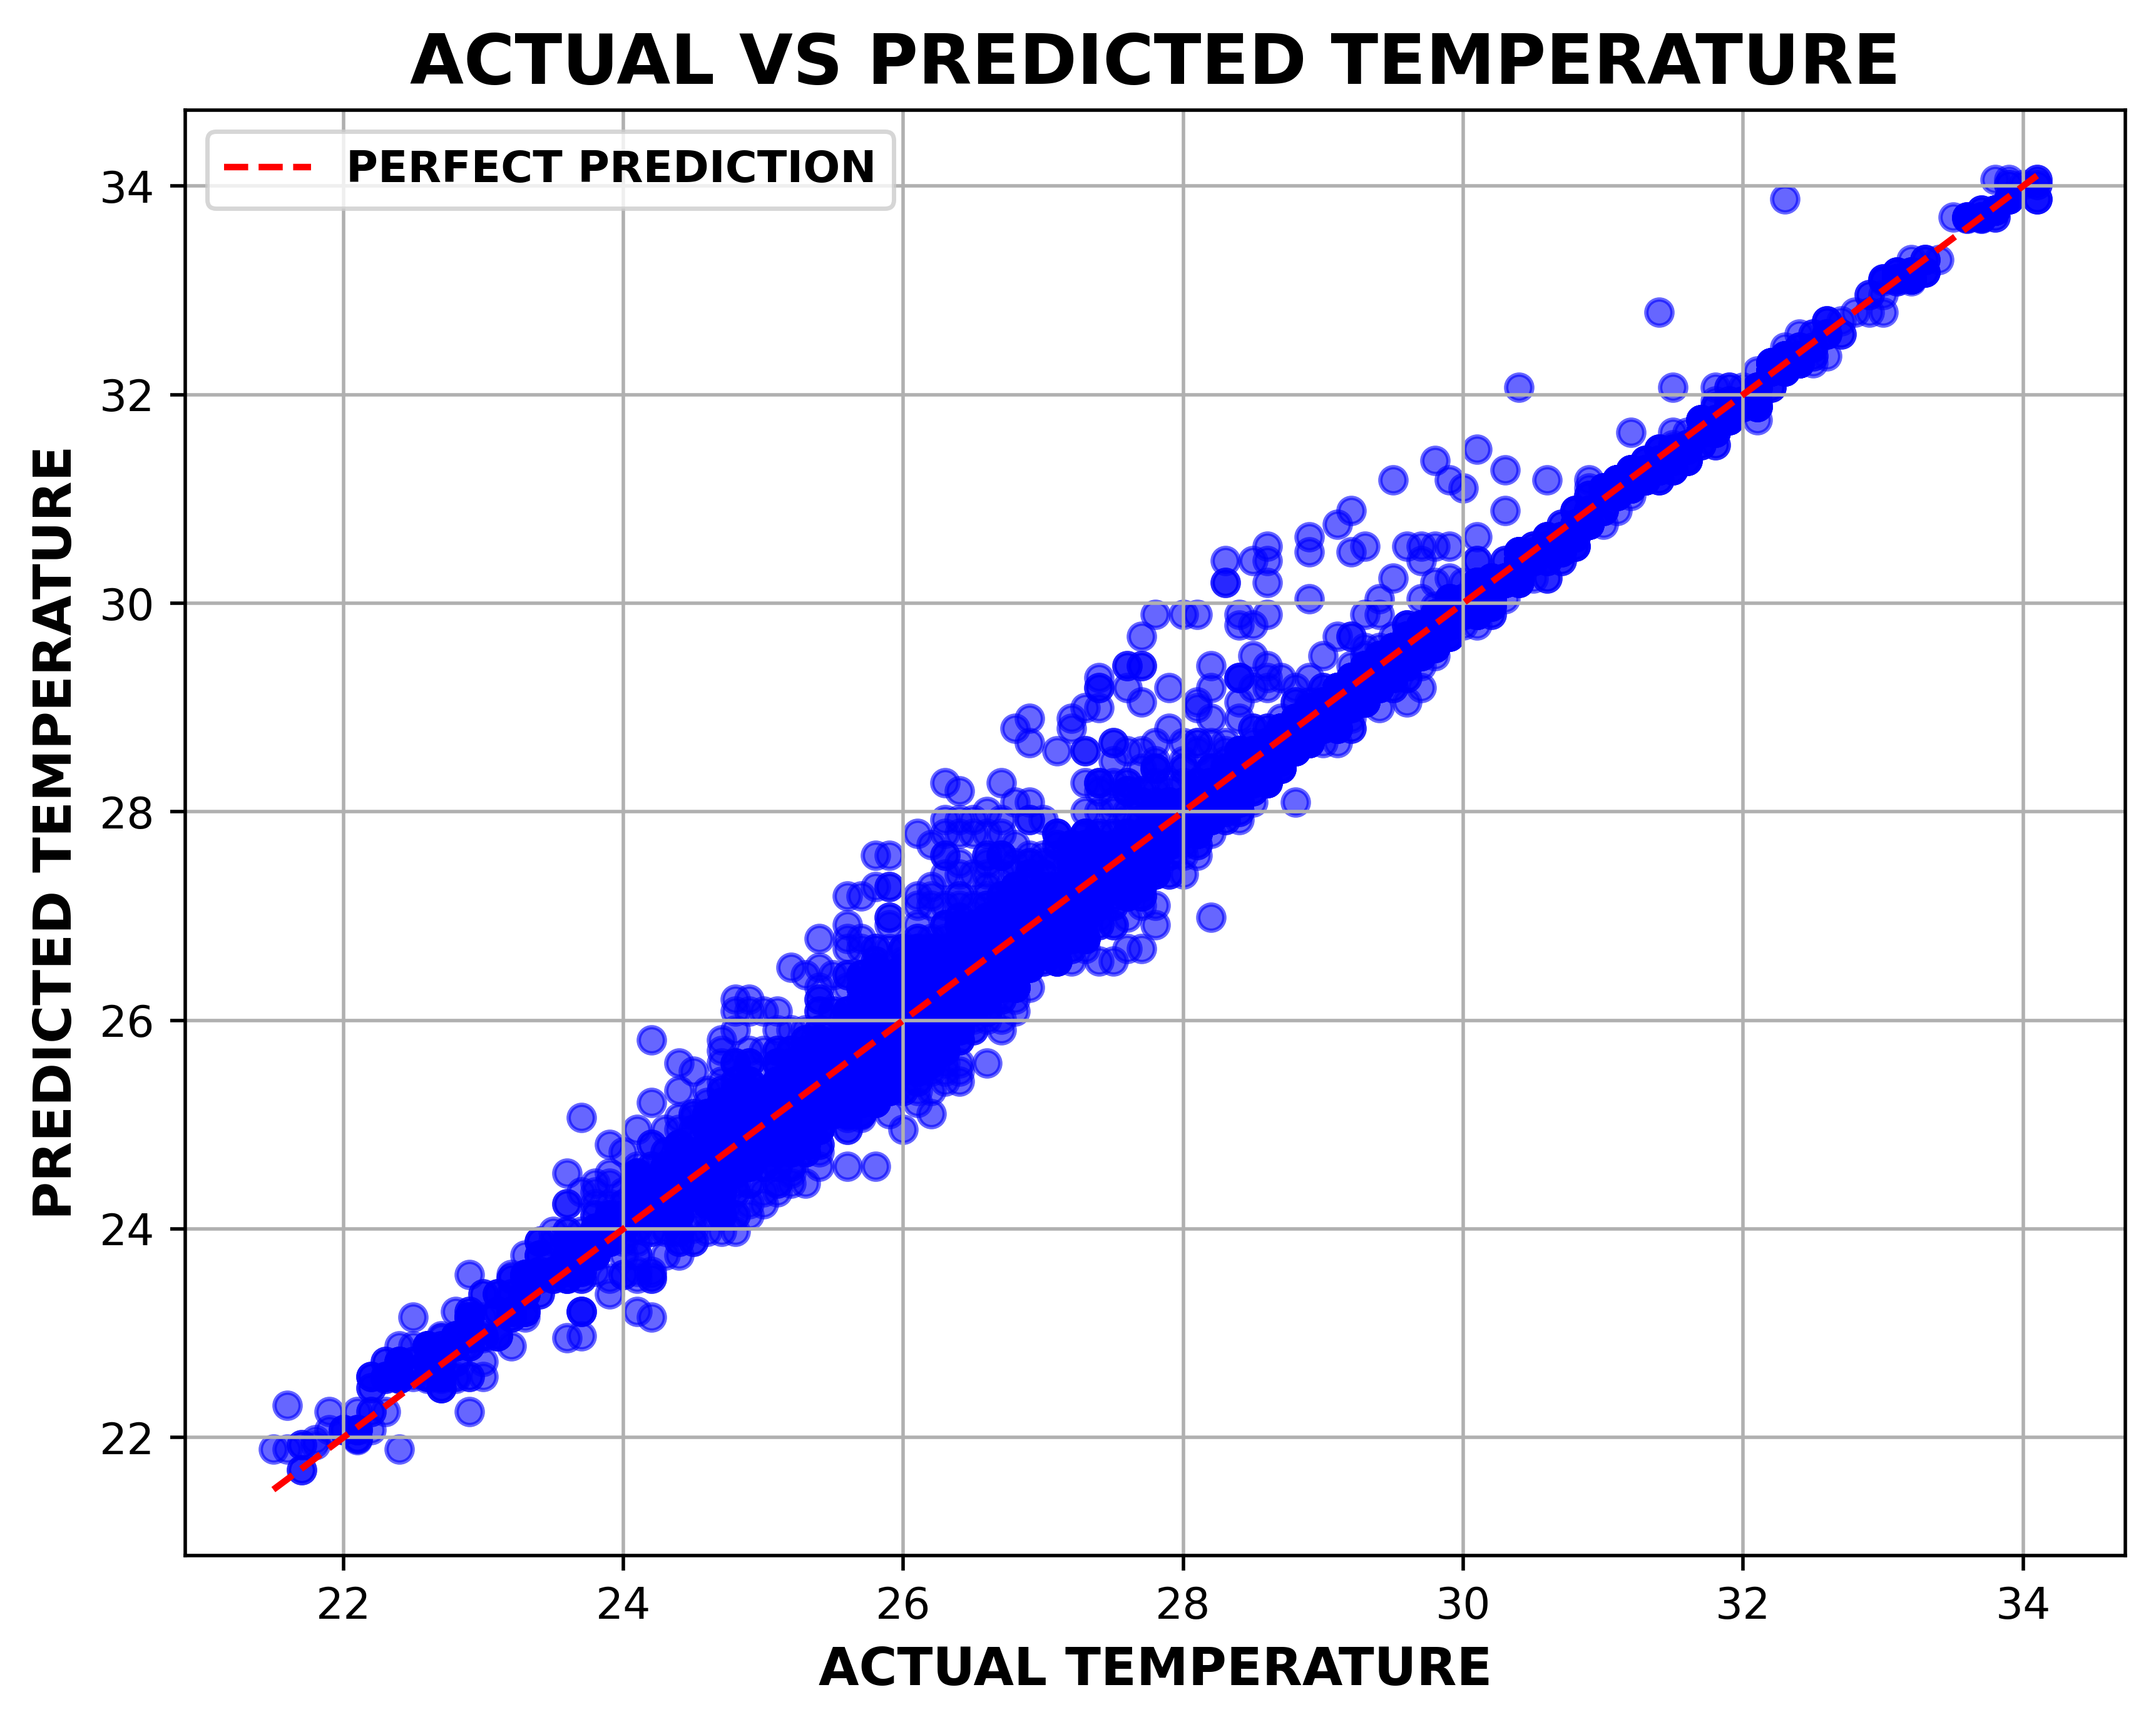

In [48]:
# CREATE FIGURE WITH SPECIFIED SIZE AND DPI
plt.figure(figsize=(8, 6), dpi=500)  # SETTING FIGURE SIZE AND DPI

# CREATE SCATTER PLOT FOR ACTUAL VS PREDICTED TEMPERATURE
plt.scatter(y_test, y_pred_temp, color='blue', alpha=0.6)  # SCATTER PLOT FOR ACTUAL VS PREDICTED

# ADD A PERFECT PREDICTION LINE (WHERE ACTUAL = PREDICTED)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='PERFECT PREDICTION')  # PERFECT PREDICTION LINE

# SET TITLE, LABELS, AND LEGENDS
plt.title("ACTUAL VS PREDICTED TEMPERATURE", fontsize=16, fontweight='bold')  # TITLE IN BOLD AND UPPERCASE
plt.xlabel("ACTUAL TEMPERATURE", fontsize=12, fontweight='bold')  # X-AXIS LABEL IN BOLD AND UPPERCASE
plt.ylabel("PREDICTED TEMPERATURE", fontsize=12, fontweight='bold')  # Y-AXIS LABEL IN BOLD AND UPPERCASE

# ADD LEGEND TO SHOW "PERFECT PREDICTION" LINE LABEL
plt.legend(fontsize=12, prop={'weight': 'bold'})  # LEGEND IN BOLD

# ENABLE GRID
plt.grid(True)  # ENABLE GRID

# DISPLAY THE PLOT
plt.show()

### RESIDUALS PLOT

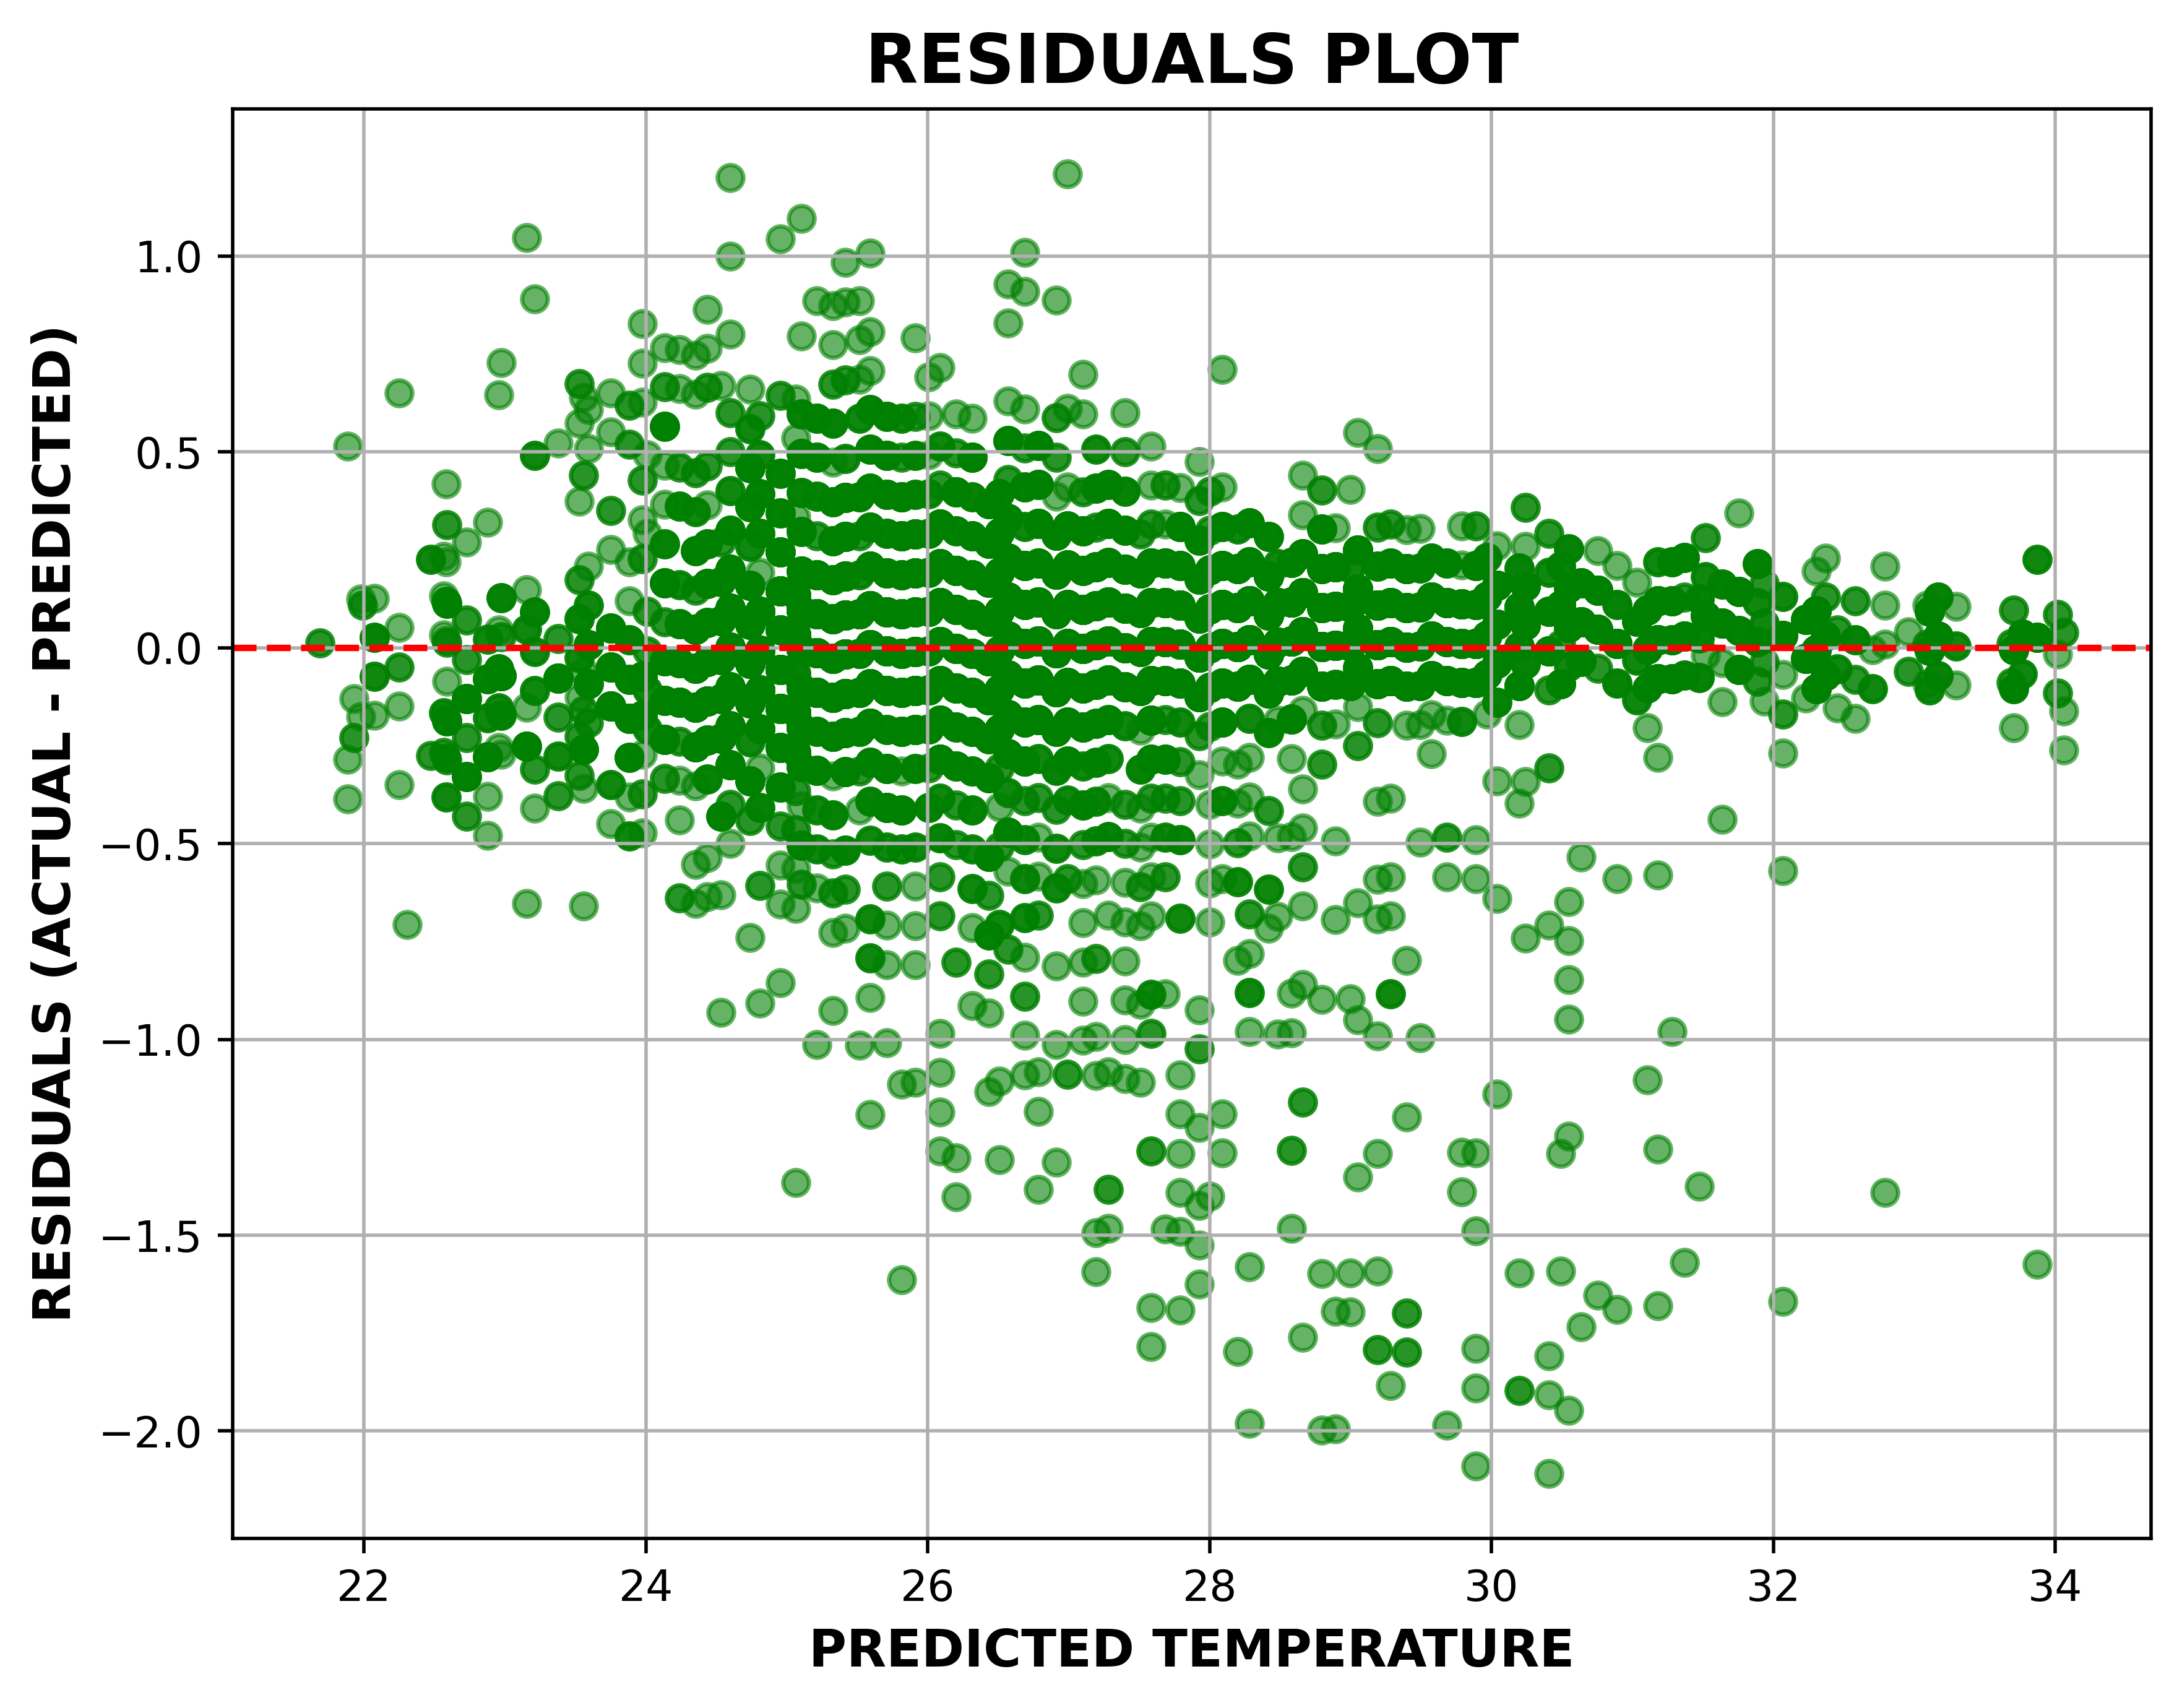

In [30]:
residuals_temp = y_test - y_pred_temp
plt.figure(figsize=(8, 6), dpi=500)
plt.scatter(y_pred_temp, residuals_temp, color='green', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')  # Zero residuals line
plt.title("RESIDUALS PLOT", fontsize=16, fontweight='bold')
plt.xlabel("PREDICTED TEMPERATURE", fontsize=12, fontweight='bold')
plt.ylabel("RESIDUALS (ACTUAL - PREDICTED)", fontsize=12, fontweight='bold')
plt.grid(True)
plt.show()

### FEATURE IMPORTANCE

C:\Users\KIIT\AppData\Local\Temp\ipykernel_6628\1514504371.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance, y=features, palette='viridis')


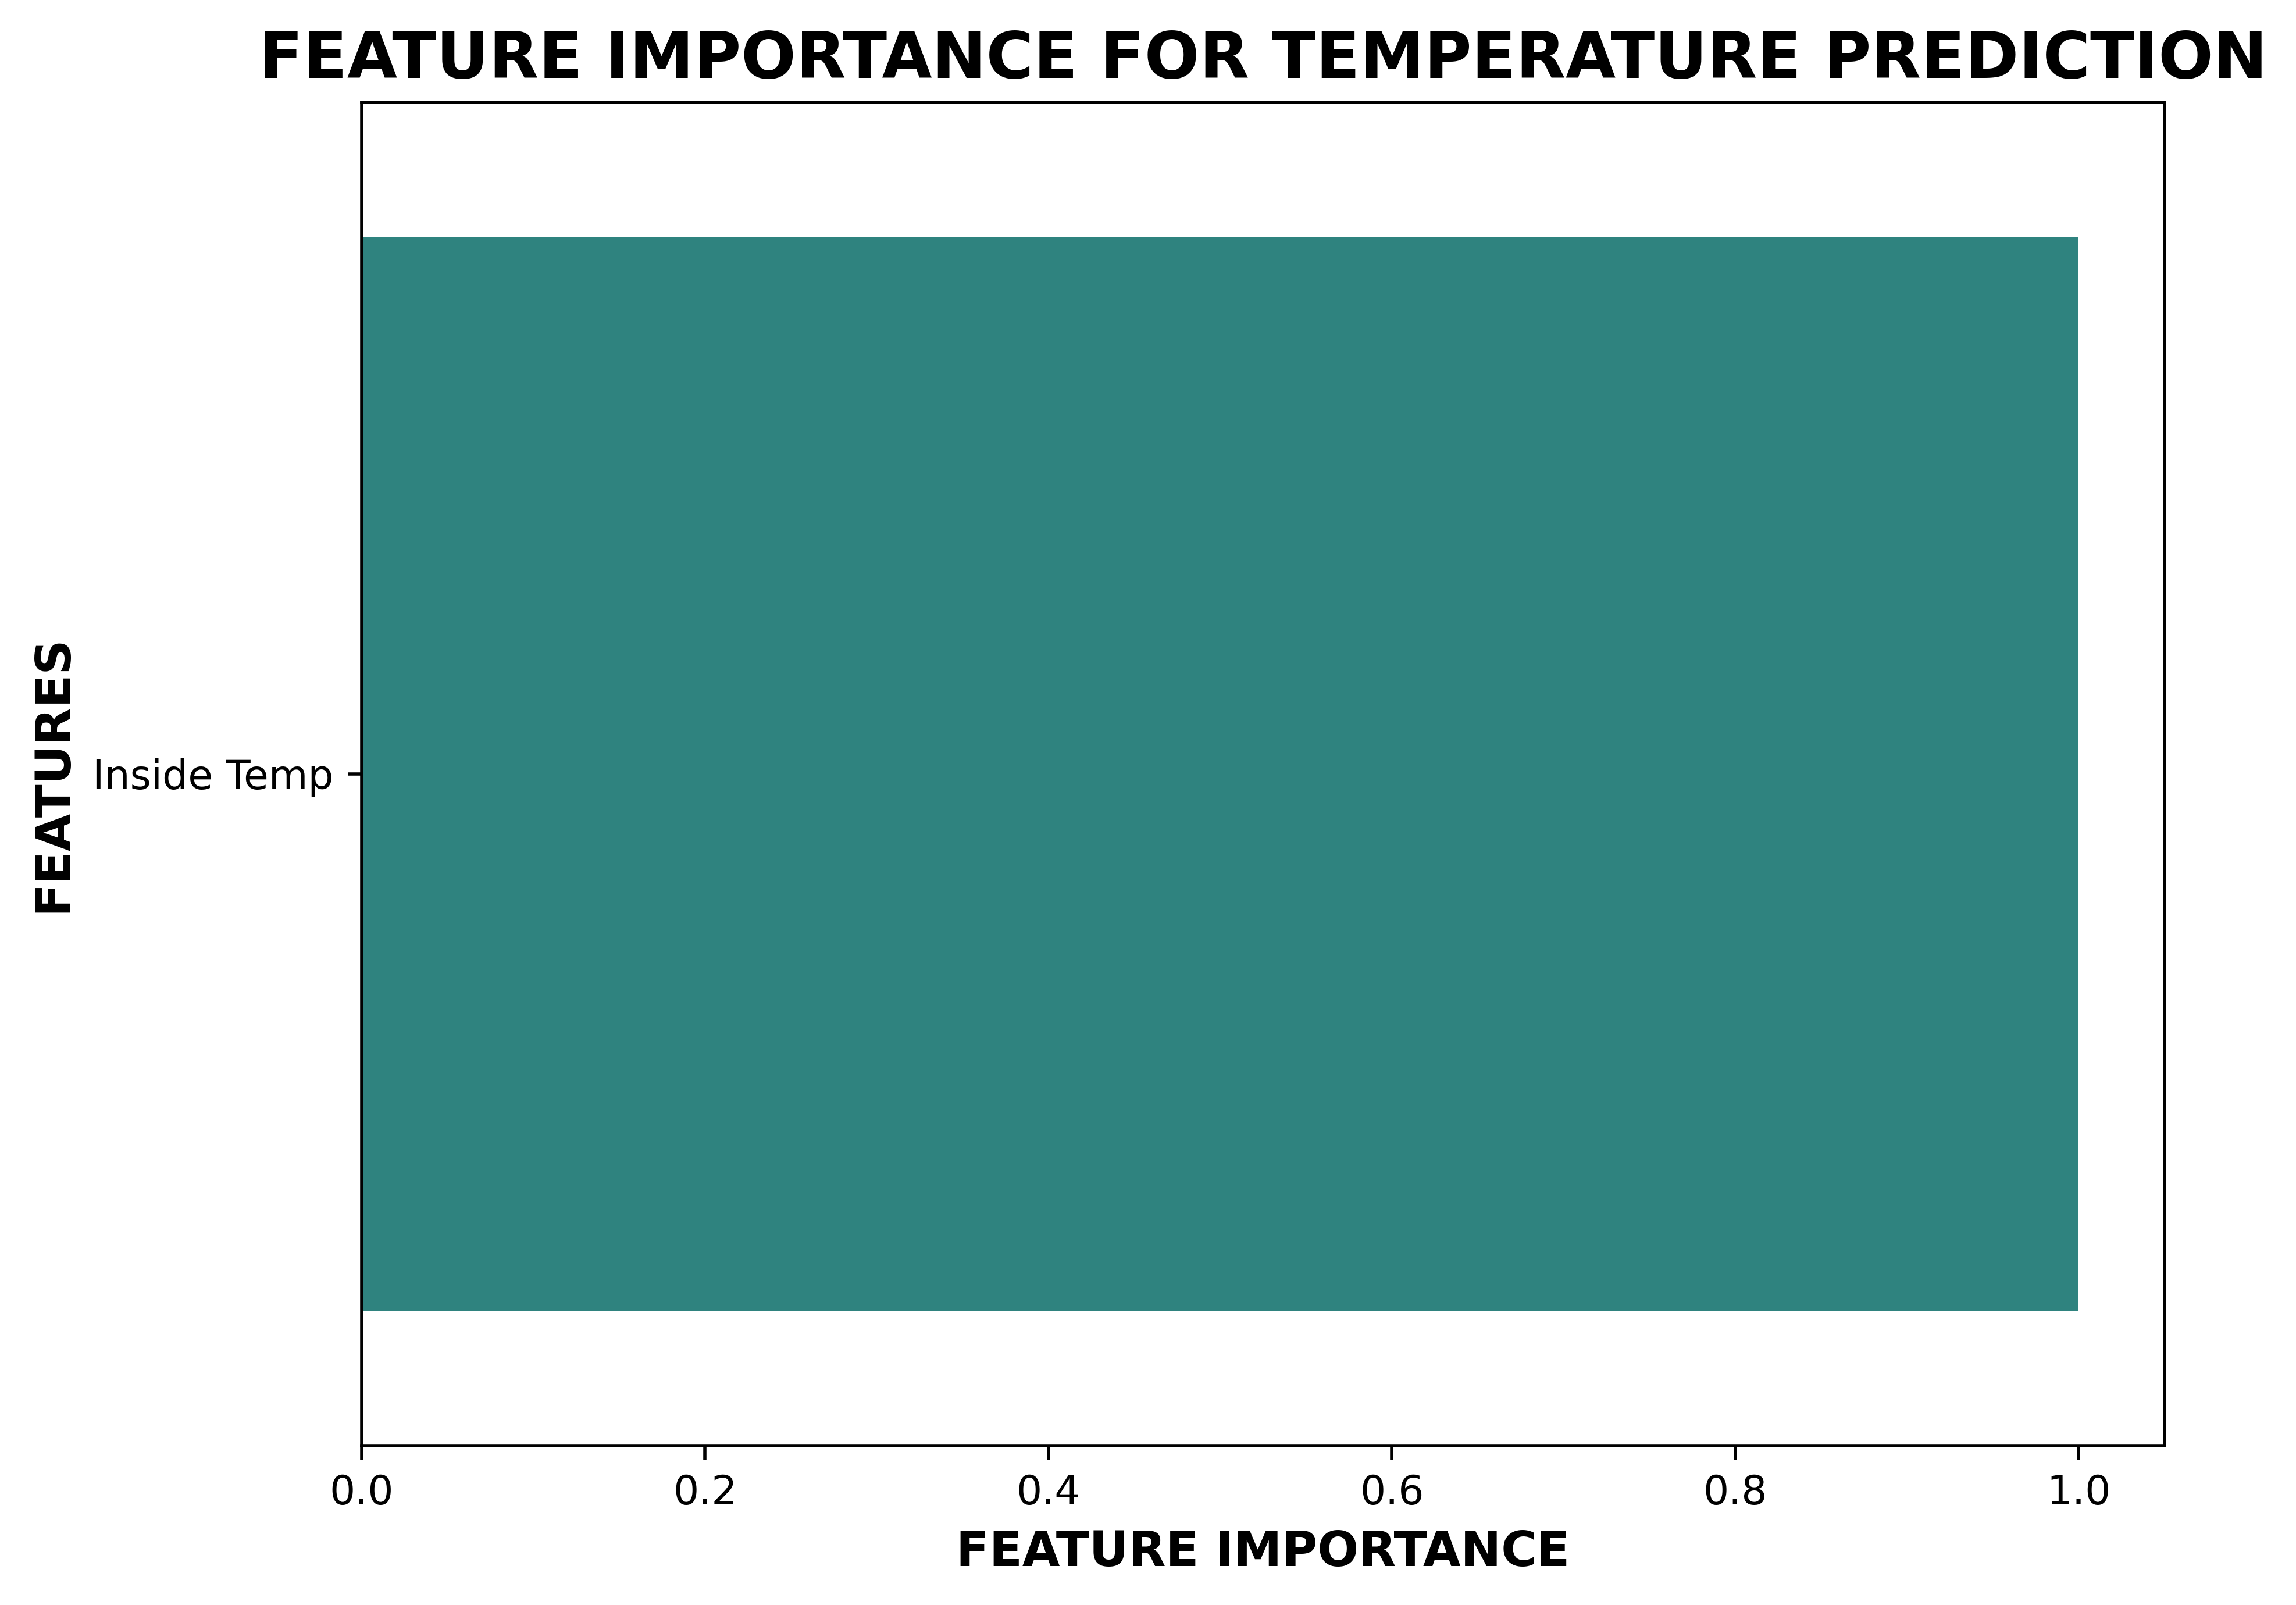

In [31]:
feature_importance = model_temp.feature_importances_
features = X_temp.columns

plt.figure(figsize=(8, 6), dpi=500)
sns.barplot(x=feature_importance, y=features, palette='viridis')
plt.title("FEATURE IMPORTANCE FOR TEMPERATURE PREDICTION", fontsize=16, fontweight='bold')
plt.xlabel("FEATURE IMPORTANCE", fontsize=12, fontweight='bold')
plt.ylabel("FEATURES", fontsize=12, fontweight='bold')
plt.show()

### HUMIDITY PREDICTION PREPROCESSING AND VISUALIZATION

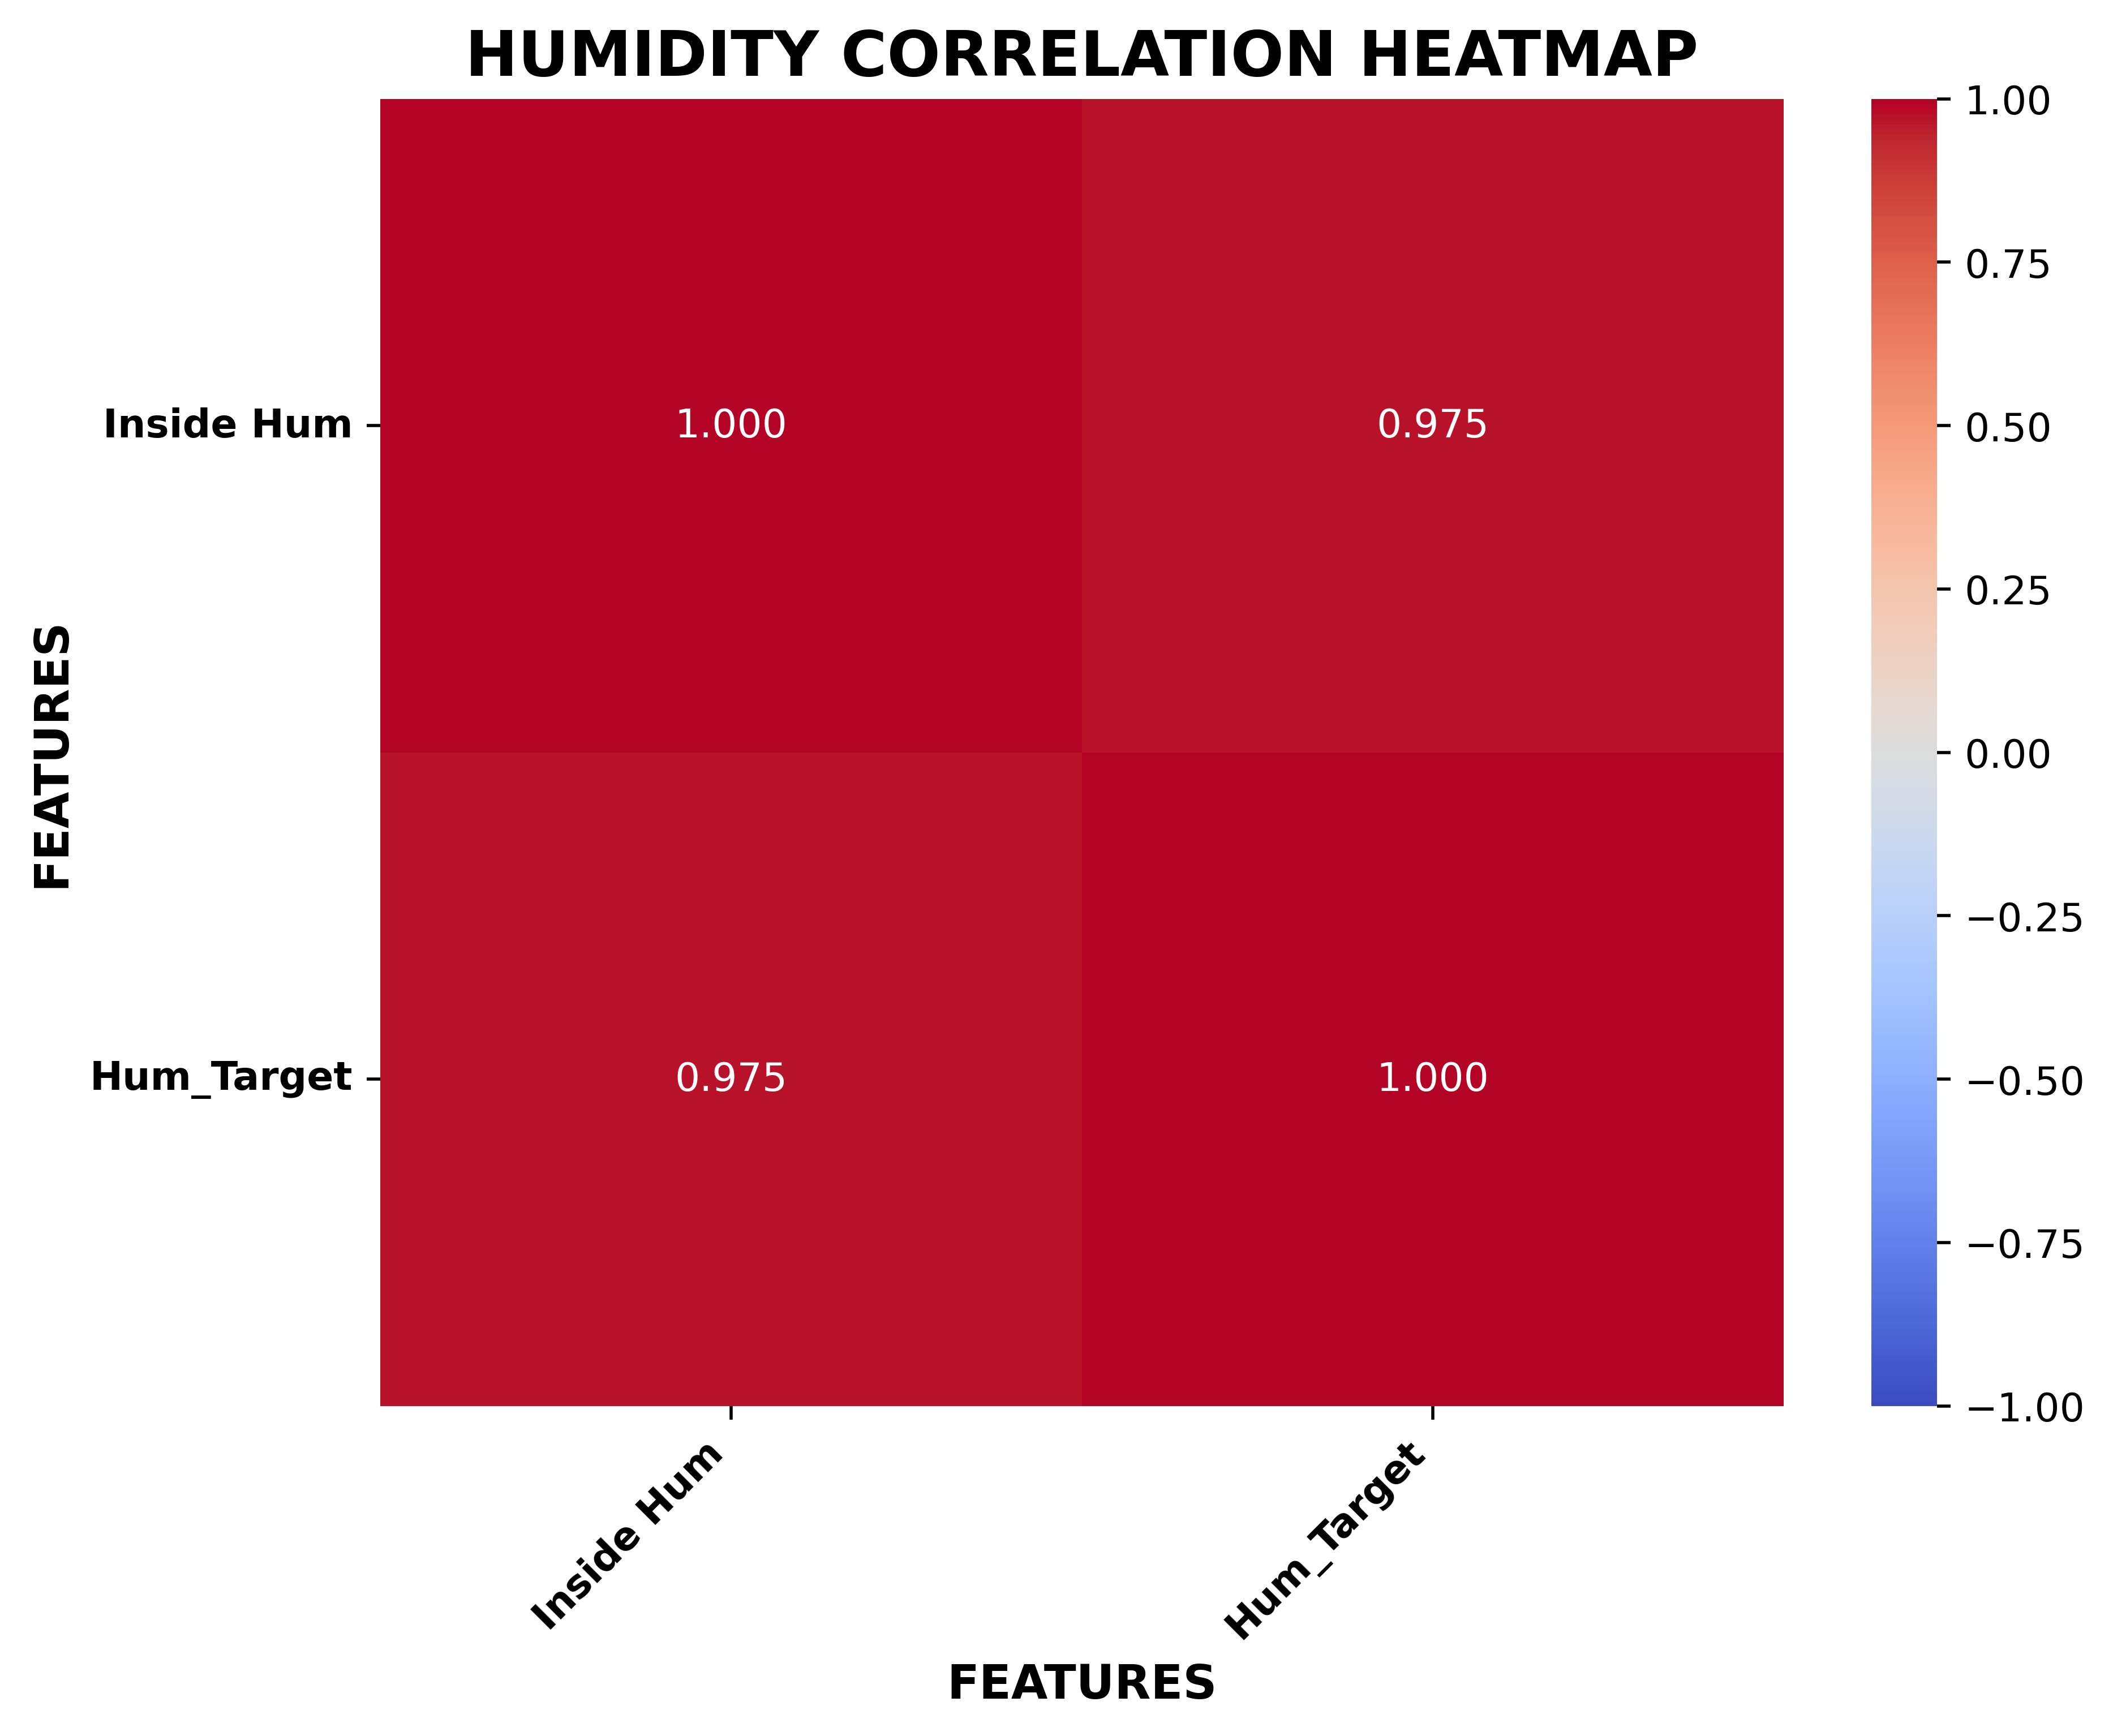

PREPARED DATASET FOR HUMIDITY PREDICTION (df_hum):
         date.time  Inside Hum  Hum_Target
0  2/24/2024 10:45        60.5        64.8
1  2/24/2024 10:50        62.7        64.9
2  2/24/2024 10:55        64.3        64.4
3  2/24/2024 11:00        64.8        64.5
4  2/24/2024 11:05        64.9        64.3


In [35]:
# STRIP WHITESPACE FROM COLUMN NAMES
df_new_data.columns = df_new_data.columns.str.strip()  # REMOVE EXTRA WHITESPACE FROM COLUMN NAMES

# REPLACE '--' WITH 0 IN THE DATASET
df_clean = df_new_data.replace('--', 0)  # REPLACE INVALID '--' VALUES WITH 0

# DROP NON-NUMERIC COLUMNS (TO KEEP ONLY RELEVANT FEATURES) BUT KEEP 'date.time'
df_conti = df_clean.drop(columns=['Prevailing Wind Direction', 'High Wind Direction'])  # KEEP 'date.time' FOR FINAL DATASET

# REMOVE ROWS WITH MISSING HUMIDITY VALUES
df_conti.dropna(subset=['Inside Hum'], inplace=True)  # REMOVE ROWS WHERE 'INSIDE HUM' IS MISSING

# CREATE TARGET VARIABLE FOR HUMIDITY PREDICTION (SHIFTING THE 'INSIDE HUM' BY -3 FOR PREDICTION)
df_conti['Hum_Target'] = df_conti['Inside Hum'].shift(-3)  # SHIFT 'INSIDE HUM' BY 3 ROWS TO CREATE TARGET VARIABLE

# REMOVE ROWS WITH NaN VALUES AFTER SHIFTING (DUE TO TARGET CREATION)
df_conti = df_conti.dropna(subset=['Hum_Target']).reset_index(drop=True)  # REMOVE ROWS THAT HAVE NaN IN 'HUM_TARGET'

# REMOVE 'date.time' COLUMN FOR CORRELATION CALCULATION (IT'S NON-NUMERIC)
df_conti_for_corr = df_conti.drop(columns=['date.time'])  # REMOVE 'date.time' COLUMN FOR CORRELATION CALCULATION

# COMPUTE PEARSON CORRELATION MATRIX FOR THE DATA
corr = df_conti_for_corr.corr(method='pearson')  # CALCULATE PEARSON CORRELATION MATRIX

# FILTER CORRELATIONS WHERE |CORRELATION| >= 0.5 (AND EXCLUDE PERFECT CORRELATION)
filtered_corr = corr.where((corr.abs() >= 0.5) & (corr != 1.00))  # FILTER OUT WEAK CORRELATIONS

# APPLY UPPER TRIANGULAR MASK TO REMOVE DUPLICATE CORRELATIONS (AS CORRELATION IS SYMMETRIC)
mask = np.triu(np.ones_like(filtered_corr, dtype=bool))  # CREATE UPPER TRIANGLE MASK
filtered_corr_masked = filtered_corr.mask(mask)  # APPLY MASK TO CORRELATION MATRIX

# EXTRACT SIGNIFICANT CORRELATION PAIRS (WHERE CORRELATION IS SIGNIFICANT)
pairs = []  # LIST TO STORE CORRELATION PAIRS
for i in range(len(filtered_corr.index)):
    for j in range(i):
        corr_value = filtered_corr.iloc[i, j]  # GET CORRELATION VALUE
        if not pd.isna(corr_value):  # IF CORRELATION VALUE IS NOT NaN
            col1 = filtered_corr.index[i]  # GET COLUMN NAME 1
            col2 = filtered_corr.columns[j]  # GET COLUMN NAME 2
            pairs.append((col1, col2, corr_value))  # ADD PAIR TO LIST

# CREATE DATAFRAME FOR CORRELATION PAIRS
pairs_df = pd.DataFrame(pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])  # CREATE DATAFRAME FOR PAIRS

# SELECT FEATURES THAT ARE CORRELATED WITH HUMIDITY
hum_pairs = pairs_df[pairs_df['Feature 1'] == 'Inside Hum']  # FILTER PAIRS WHERE 'INSIDE HUM' IS FEATURE 1

# FINAL DATASET FOR HUMIDITY PREDICTION (KEEPING 'date.time' IN THE FINAL DATASET)
df_hum = df_conti[['date.time', 'Inside Hum', 'Hum_Target'] + hum_pairs['Feature 2'].tolist()]  # CREATE FINAL DATASET

# COMPUTE PEARSON CORRELATION FOR THE FINAL DATASET (INCLUDING TARGET)
hum_corr = df_hum.drop(columns=['date.time']).corr(method='pearson')  # DROP 'date.time' FOR CORRELATION CALCULATION

# PLOT HEATMAP FOR CORRELATION OF HUMIDITY PREDICTION FEATURES
plt.figure(figsize=(8, 6), dpi=500)  # SET FIGURE SIZE AND DPI
sns.heatmap(hum_corr, annot=True, cmap="coolwarm", fmt=".3f", vmin=-1, vmax=1)  # PLOT HEATMAP
plt.title("HUMIDITY CORRELATION HEATMAP", fontsize=16, fontweight='bold')  # TITLE IN BOLD AND UPPERCASE
plt.xlabel("FEATURES", fontsize=12, fontweight='bold')  # X-AXIS LABEL IN BOLD AND UPPERCASE
plt.ylabel("FEATURES", fontsize=12, fontweight='bold')  # Y-AXIS LABEL IN BOLD AND UPPERCASE
plt.xticks(fontsize=10, rotation=45, ha='right', fontweight='bold')  # X-AXIS TICK LABELS
plt.yticks(fontsize=10, rotation=0, ha='right', fontweight='bold')  # Y-AXIS TICK LABELS
plt.show()  # DISPLAY THE HEATMAP

# DISPLAY FINAL PREPARED DATASET FOR HUMIDITY PREDICTION
print("PREPARED DATASET FOR HUMIDITY PREDICTION (df_hum):")
print(df_hum.head())  # DISPLAY FIRST FEW ROWS OF FINAL DATASET

### PREPARE DATA FOR HUMIDITY PREDICTION

In [36]:
# SELECT FEATURES AND TARGET VARIABLE FOR HUMIDITY PREDICTION
df_hum = df_conti[['date.time', 'Inside Hum', 'Hum_Target'] + hum_pairs['Feature 2'].tolist()]  # CREATE FINAL DATASET
X_hum = df_hum.drop(columns=['date.time', 'Hum_Target'])  # FEATURES (EXCLUDE DATE AND TARGET)
y_hum = df_hum['Hum_Target']  # TARGET (HUMIDITY TO PREDICT)

### SPLIT DATA INTO TRAINING AND TEST SET

In [37]:
X_train_hum, X_test_hum, y_train_hum, y_test_hum = train_test_split(X_hum, y_hum, test_size=0.2, random_state=42) 

### CREATE AND TRAIN THE RANDOM FOREST REGRESSOR MODEL FOR HUMIDITY

In [38]:
model_hum = RandomForestRegressor(n_estimators=100, random_state=42)  # RANDOM FOREST REGRESSOR WITH 100 ESTIMATORS
model_hum.fit(X_train_hum, y_train_hum)  # FIT THE MODEL ON THE TRAINING DATA

RandomForestRegressor(random_state=42)

### MAKE PREDICTIONS AND EVALUATE THE MODEL

In [39]:
y_pred_hum = model_hum.predict(X_test_hum)  # PREDICT HUMIDITY ON TEST DATA

### EVALUATE THE MODEL

In [40]:
# CALCULATE MEAN ABSOLUTE ERROR (MAE)
mae_temp = mean_absolute_error(y_test, y_pred_temp)  # MEAN ABSOLUTE ERROR

# CALCULATE MEAN SQUARED ERROR (MSE)
mse_temp = mean_squared_error(y_test, y_pred_temp)  # MEAN SQUARED ERROR

# MANUALLY CALCULATE ROOT MEAN SQUARED ERROR (RMSE)
rmse_temp = mse_temp**0.5  # ROOT MEAN SQUARED ERROR (TAKE SQUARE ROOT OF MSE)

# CALCULATE R-SQUARED VALUE (GOODNESS OF FIT)
r2_temp = r2_score(y_test, y_pred_temp)  # R-SQUARED VALUE

### PRINT THE EVALUATION METRICS FOR HUMIDITY PREDICTION

In [41]:
# PRINT THE EVALUATION METRICS FOR TEMPERATURE PREDICTION
print("TEMPERATURE PREDICTION EVALUATION:")
print(f"MAE: {mae_temp:.4f}")
print(f"MSE: {mse_temp:.4f}")
print(f"RMSE: {rmse_temp:.4f}")
print(f"R2 Score: {r2_temp:.4f}")

TEMPERATURE PREDICTION EVALUATION:
MAE: 0.1499
MSE: 0.0660
RMSE: 0.2569
R2 Score: 0.9854


# PLOTS

### ACTUAL VS PREDICTED HUMIDITY

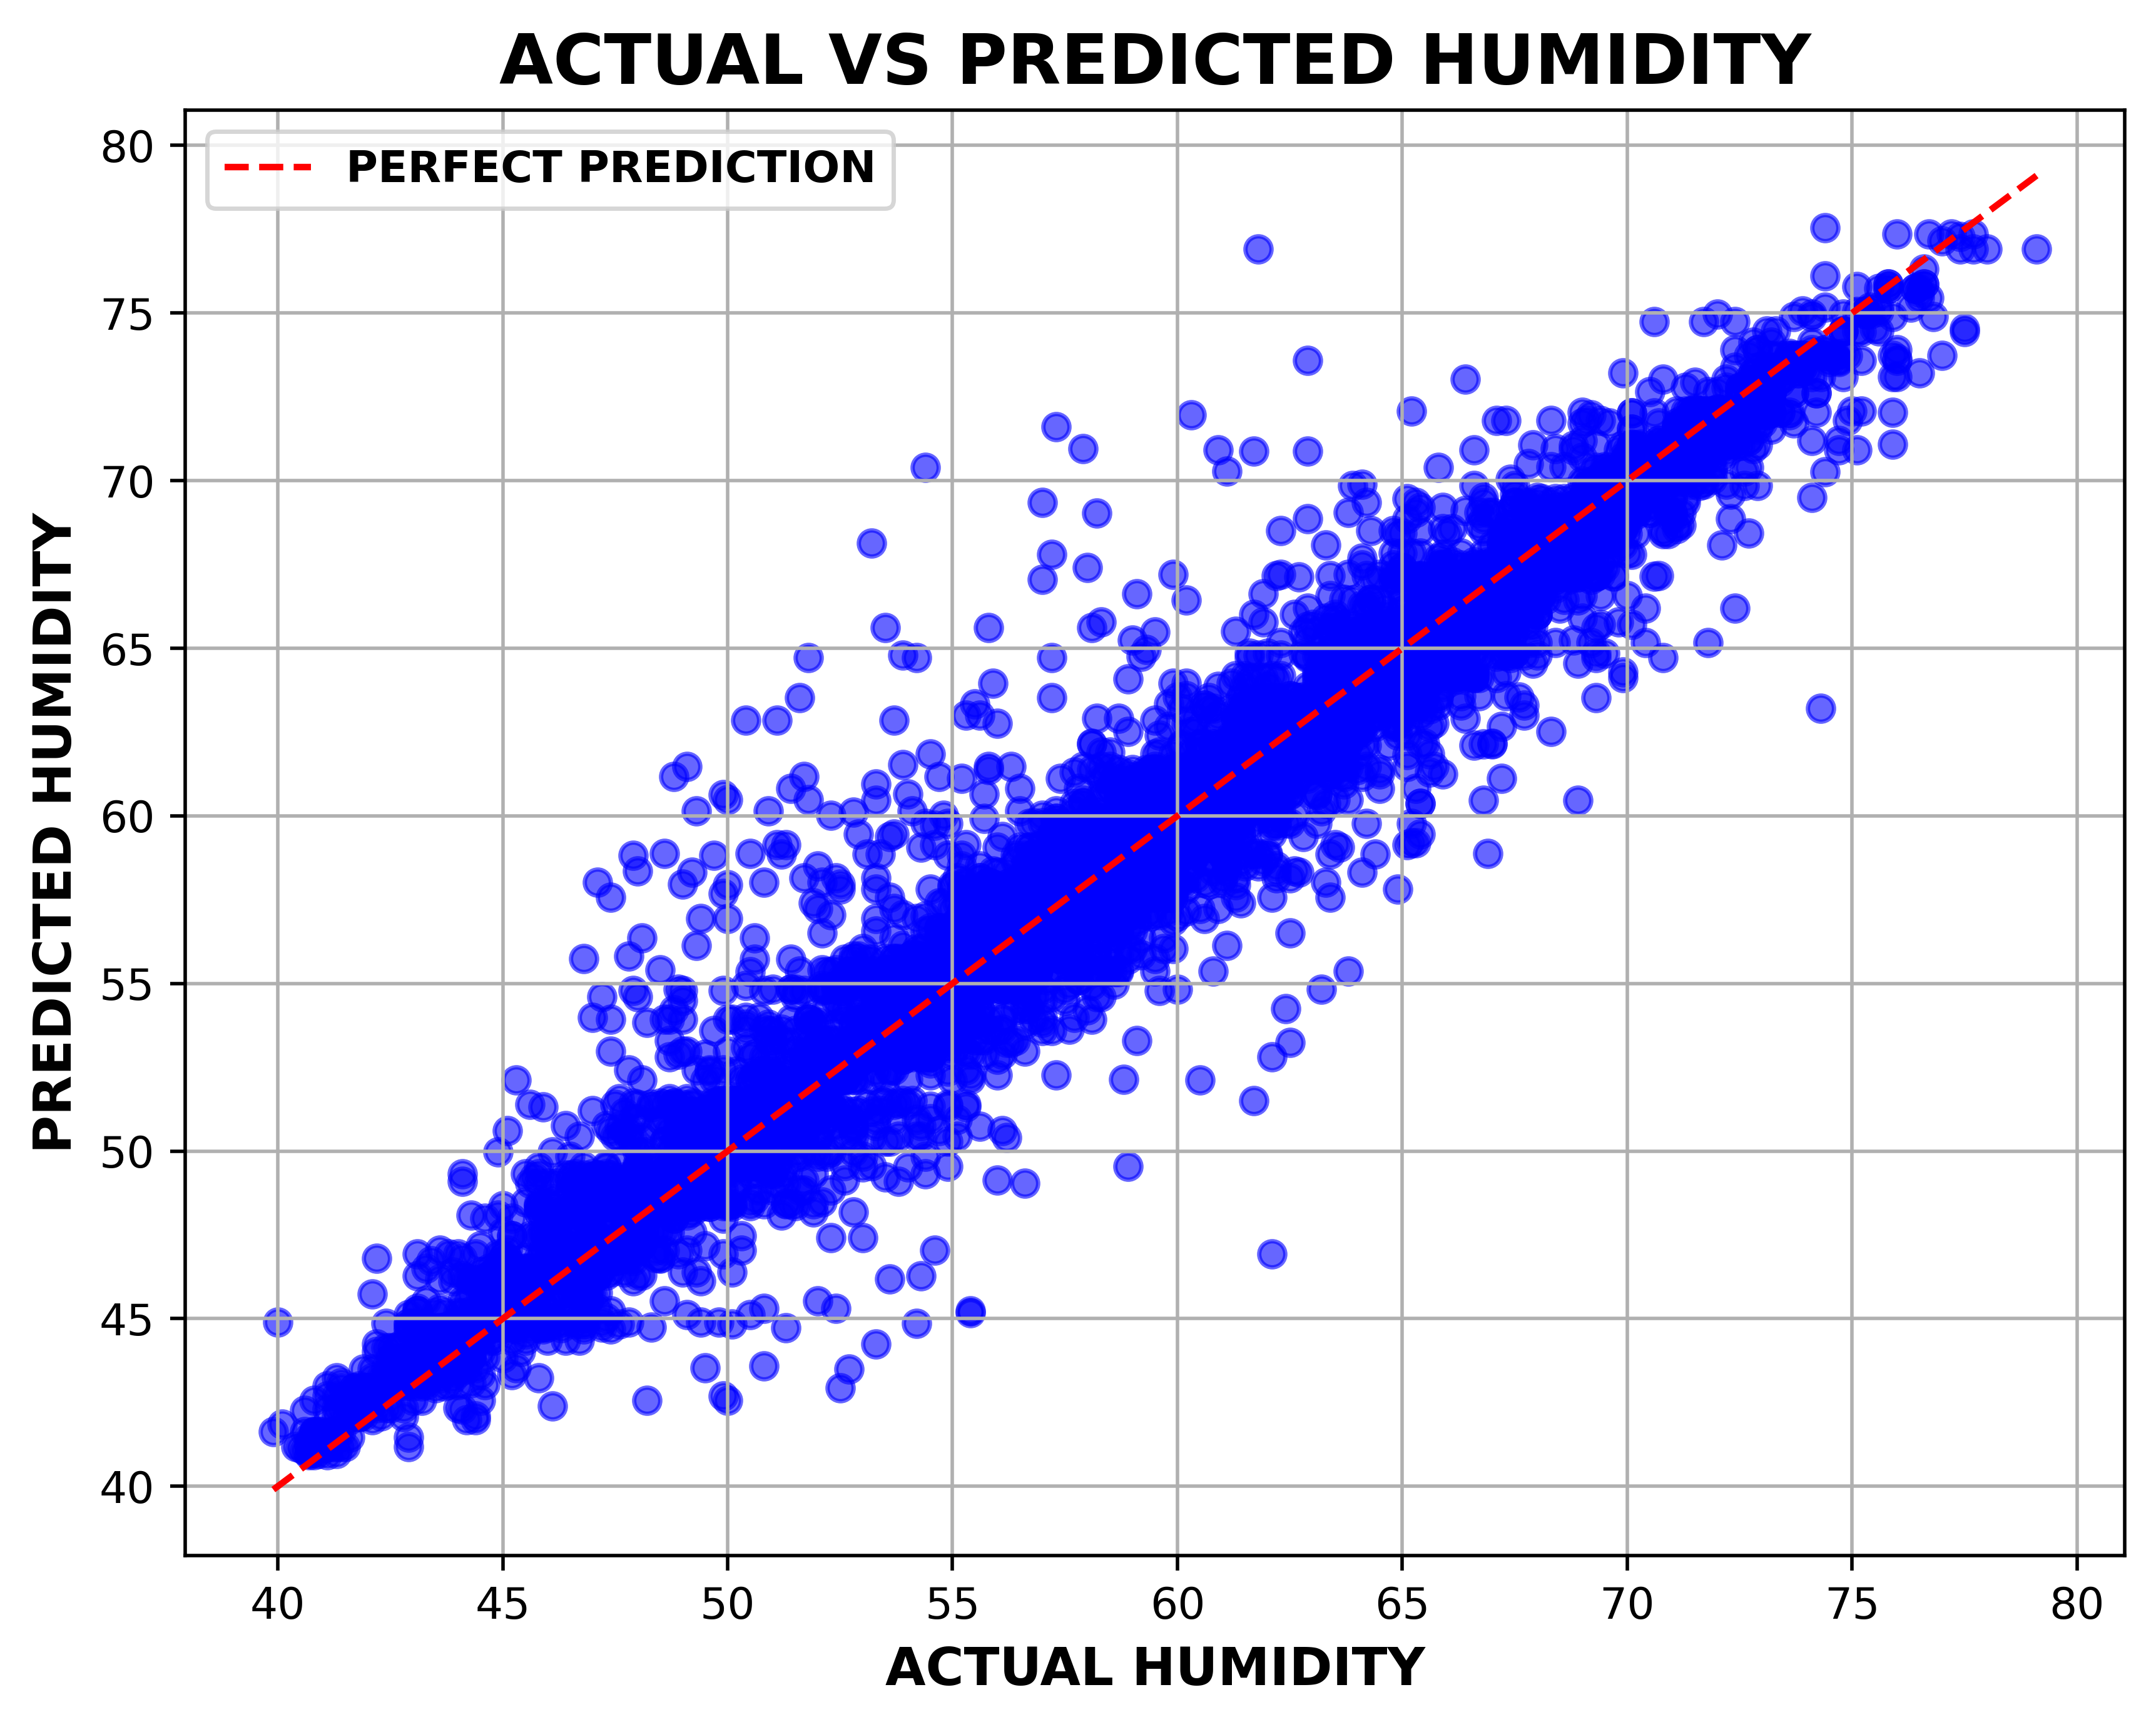

In [ ]:
# CREATE FIGURE WITH SPECIFIED SIZE AND DPI
plt.figure(figsize=(8, 6), dpi=500)  # SETTING FIGURE SIZE AND DPI

# CREATE SCATTER PLOT FOR ACTUAL VS PREDICTED HUMIDITY
plt.scatter(y_test_hum, y_pred_hum, color='blue', alpha=0.6)  # SCATTER PLOT FOR ACTUAL VS PREDICTED

# ADD A PERFECT PREDICTION LINE (WHERE ACTUAL = PREDICTED)
plt.plot([min(y_test_hum), max(y_test_hum)], [min(y_test_hum), max(y_test_hum)], color='red', linestyle='--', label='PERFECT PREDICTION')  # PERFECT PREDICTION LINE

# SET TITLE, LABELS, AND LEGENDS
plt.title("ACTUAL VS PREDICTED HUMIDITY", fontsize=16, fontweight='bold')  # TITLE IN BOLD AND UPPERCASE
plt.xlabel("ACTUAL HUMIDITY", fontsize=12, fontweight='bold')  # X-AXIS LABEL IN BOLD AND UPPERCASE
plt.ylabel("PREDICTED HUMIDITY", fontsize=12, fontweight='bold')  # Y-AXIS LABEL IN BOLD AND UPPERCASE

# LEGEND IN BOLD AND UPPERCASE
plt.legend(fontsize=12, prop={'weight': 'bold'})  # LEGEND IN BOLD

# ENABLE GRID
plt.grid(True) 

# DISPLAY THE PLOT
plt.show() 

### RESIDUALS PLOT

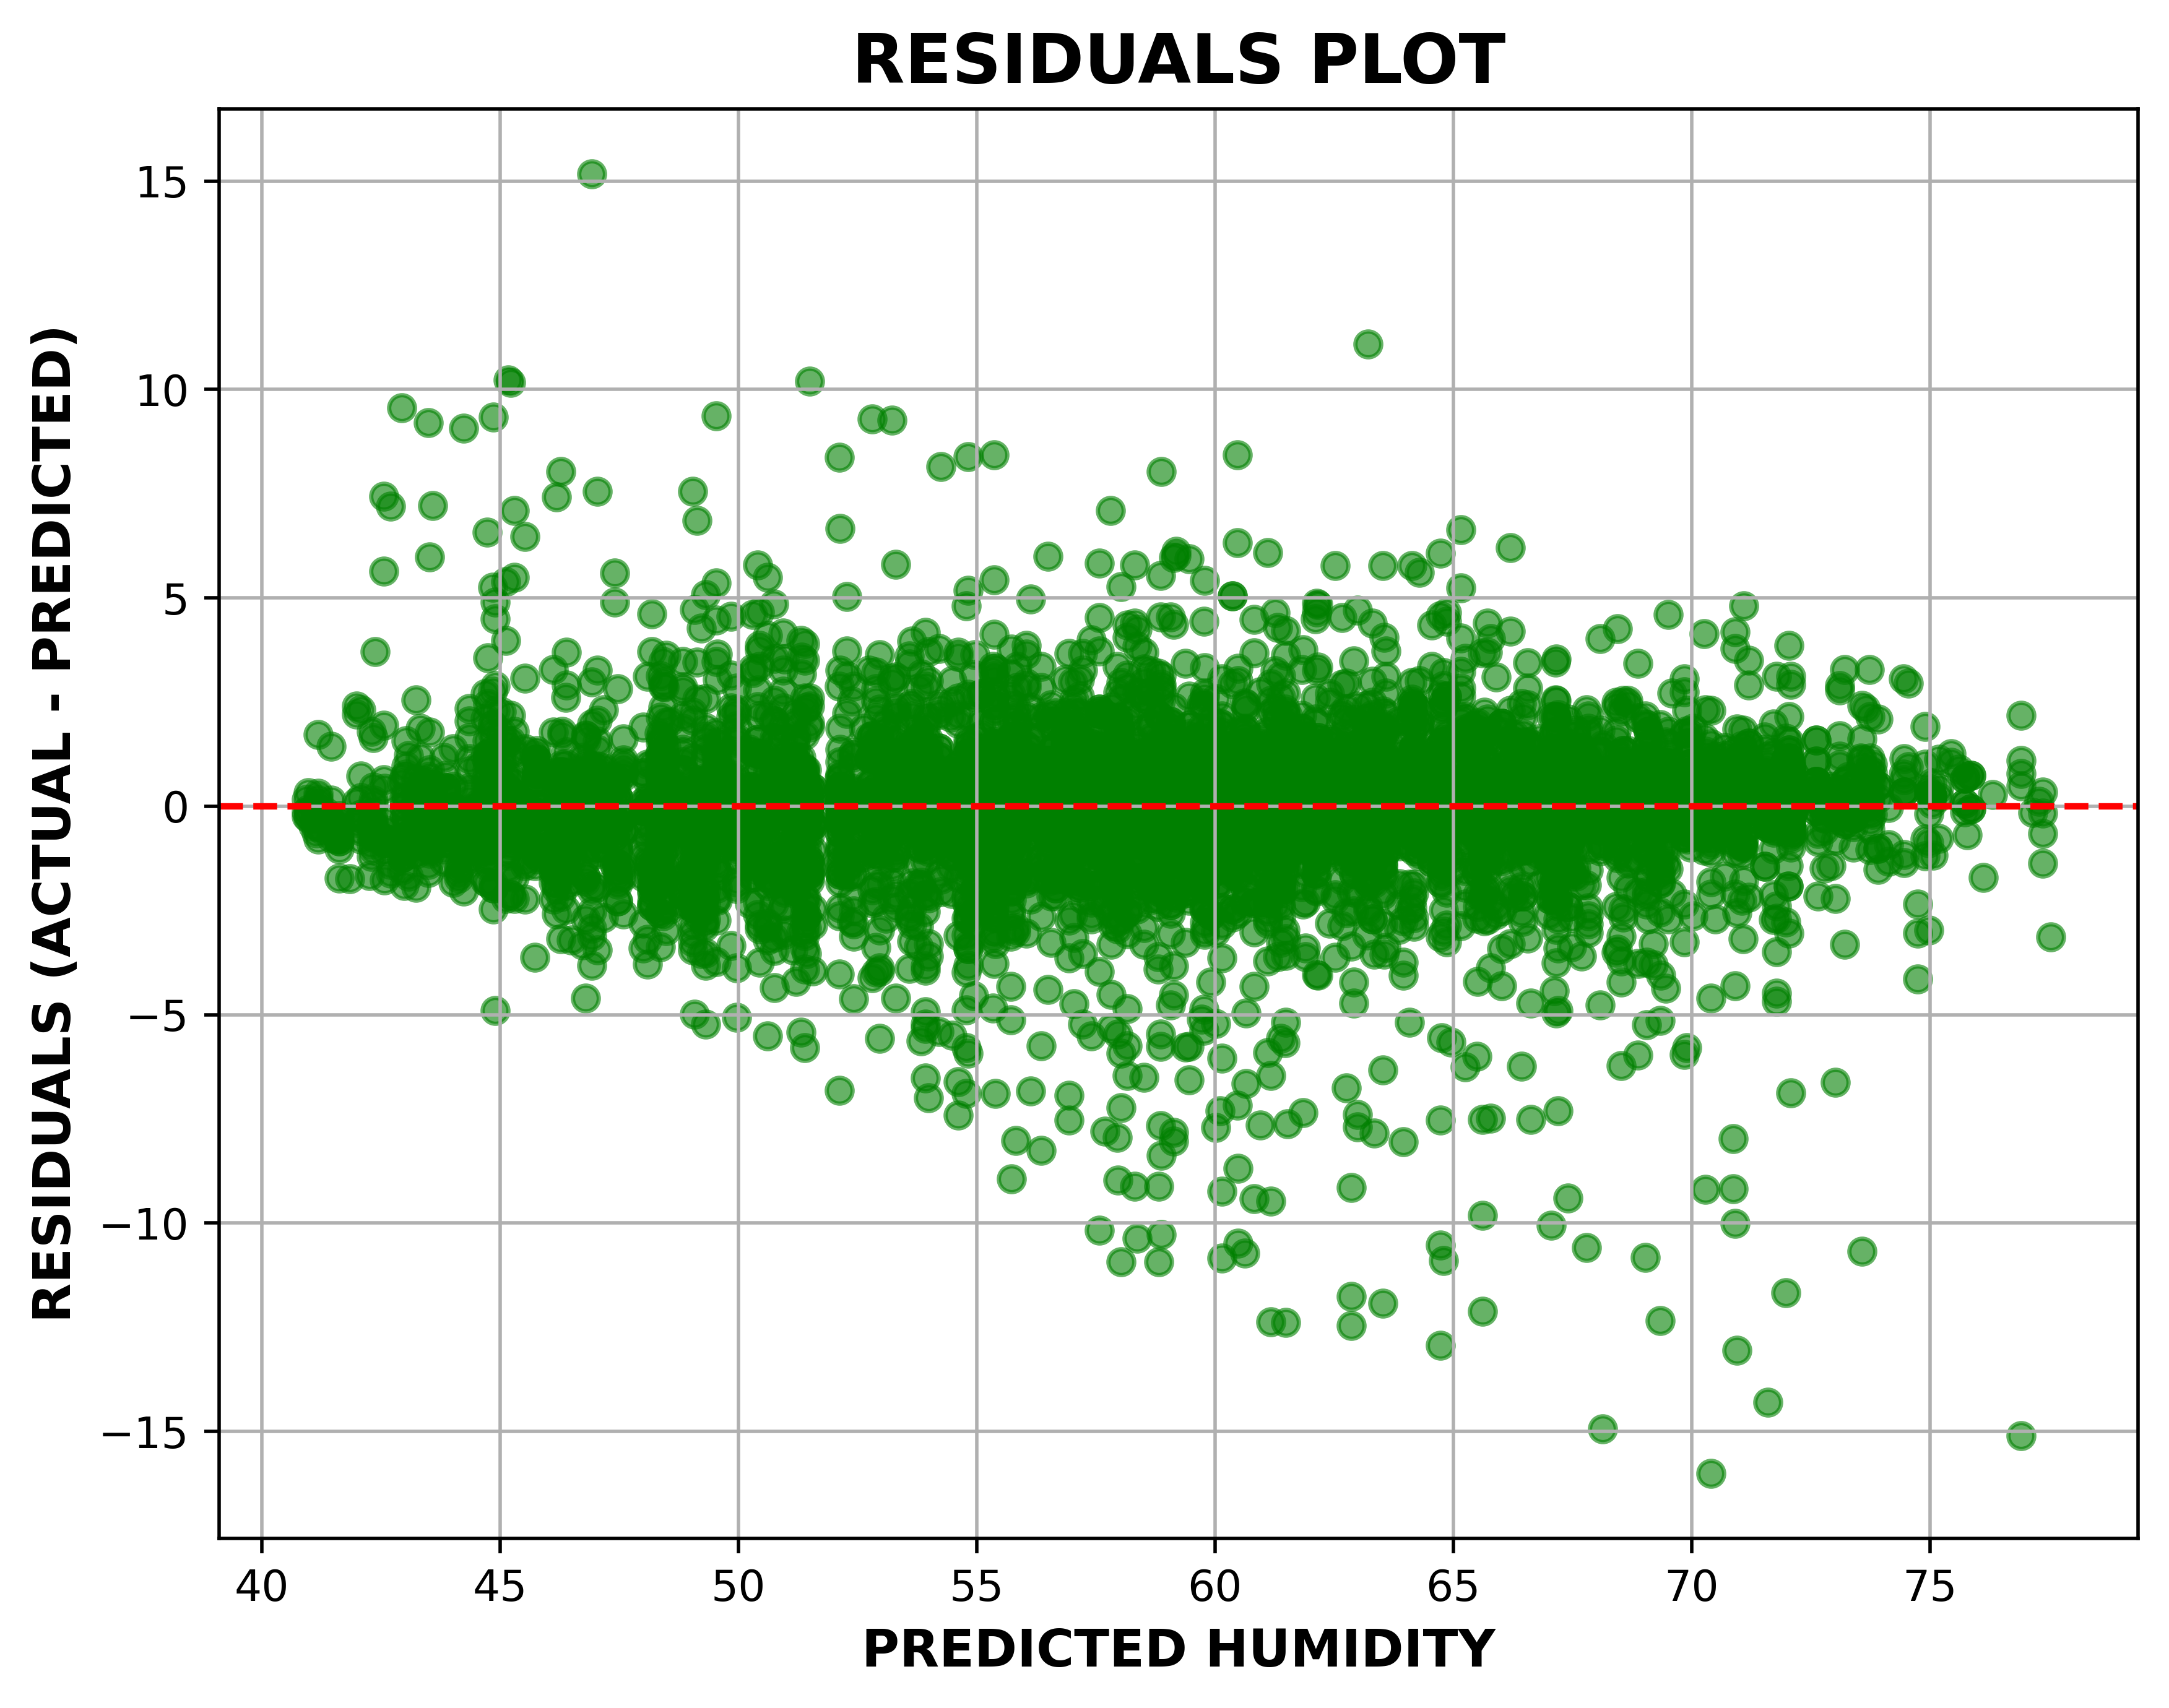

In [44]:
residuals_hum = y_test_hum - y_pred_hum  # RESIDUALS (ACTUAL - PREDICTED)
plt.figure(figsize=(8, 6), dpi=500)  # SETTING FIGURE SIZE AND DPI
plt.scatter(y_pred_hum, residuals_hum, color='green', alpha=0.6)  # SCATTER PLOT FOR RESIDUALS

# ADD A ZERO RESIDUALS LINE
plt.axhline(y=0, color='red', linestyle='--')  # ZERO RESIDUALS LINE
plt.title("RESIDUALS PLOT", fontsize=16, fontweight='bold')  # TITLE IN BOLD AND UPPERCASE
plt.xlabel("PREDICTED HUMIDITY", fontsize=12, fontweight='bold')  # X-AXIS LABEL IN BOLD AND UPPERCASE
plt.ylabel("RESIDUALS (ACTUAL - PREDICTED)", fontsize=12, fontweight='bold')  # Y-AXIS LABEL IN BOLD AND UPPERCASE
plt.grid(True)  # ENABLE GRID
plt.show()  # DISPLAY THE PLOT

### FEATURE IMPORTANCE

C:\Users\KIIT\AppData\Local\Temp\ipykernel_6628\2248367986.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_hum, y=features_hum, palette='viridis')  # PLOTTING FEATURE IMPORTANCE


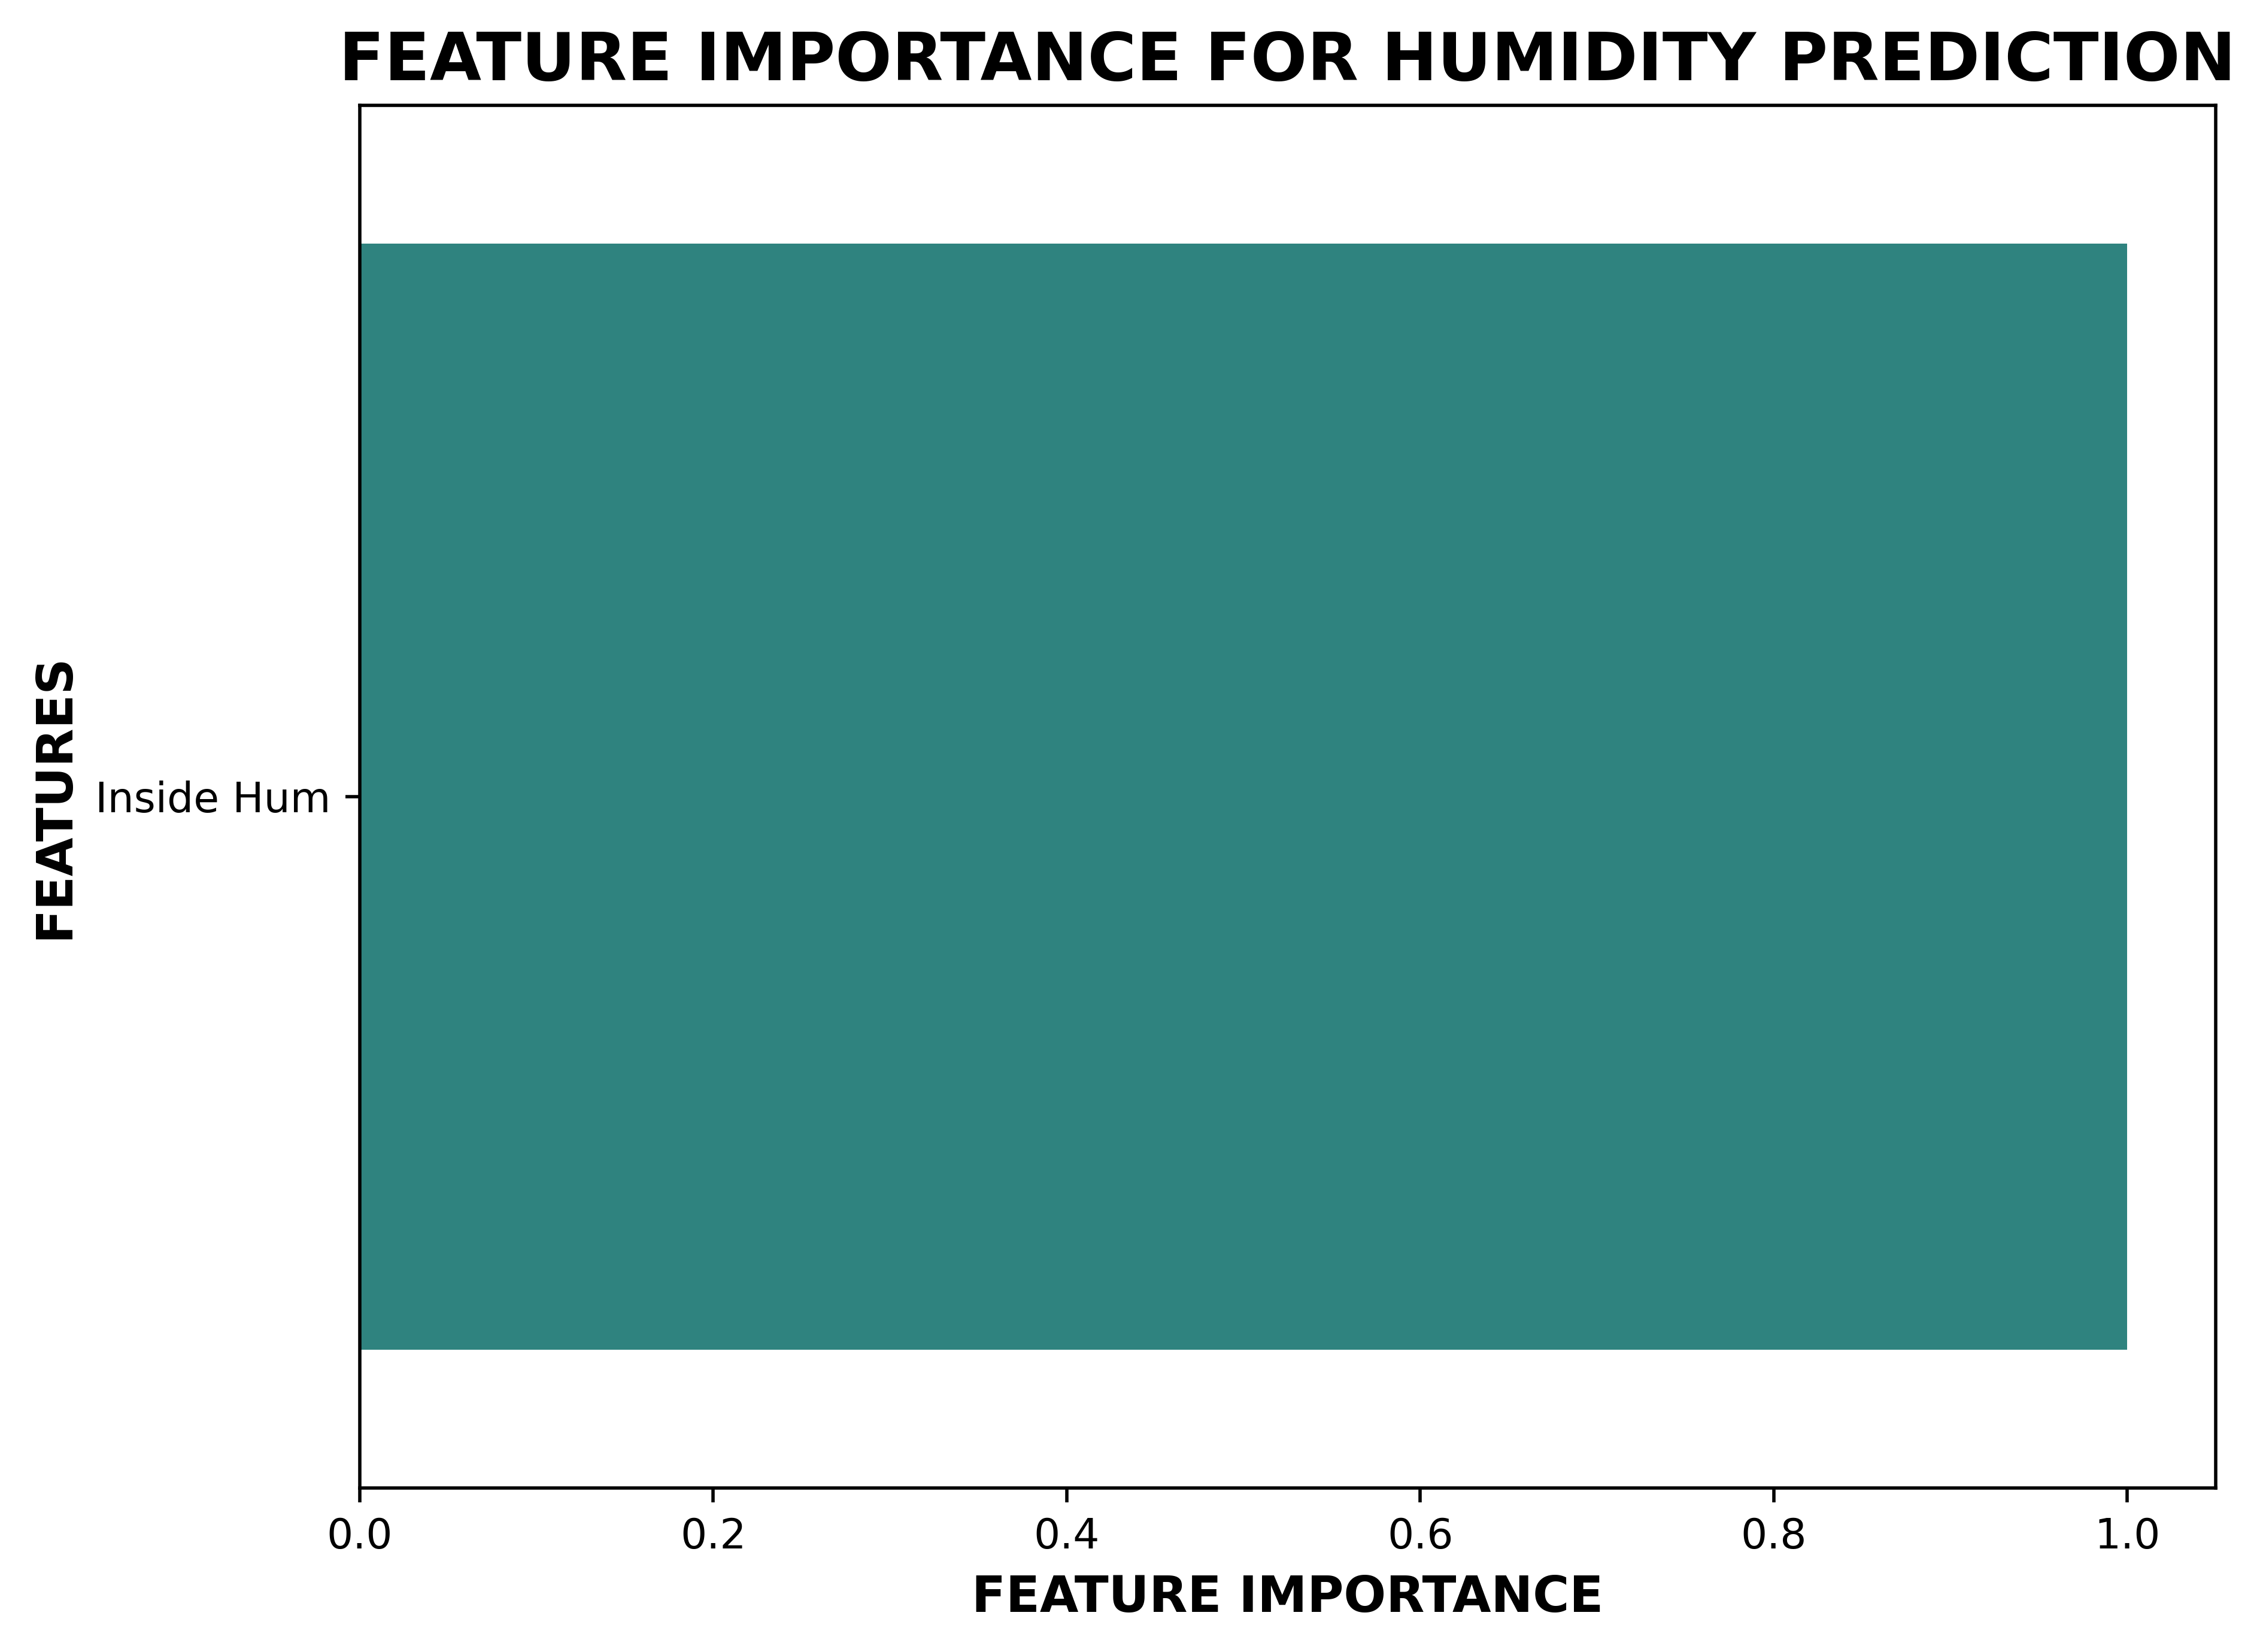

In [45]:
feature_importance_hum = model_hum.feature_importances_  # GET FEATURE IMPORTANCES
features_hum = X_hum.columns  # GET FEATURE NAMES

plt.figure(figsize=(8, 6), dpi=500)  # SETTING FIGURE SIZE AND DPI
sns.barplot(x=feature_importance_hum, y=features_hum, palette='viridis')  # PLOTTING FEATURE IMPORTANCE
plt.title("FEATURE IMPORTANCE FOR HUMIDITY PREDICTION", fontsize=16, fontweight='bold')  # TITLE IN BOLD AND UPPERCASE
plt.xlabel("FEATURE IMPORTANCE", fontsize=12, fontweight='bold')  # X-AXIS LABEL IN BOLD AND UPPERCASE
plt.ylabel("FEATURES", fontsize=12, fontweight='bold')  # Y-AXIS LABEL IN BOLD AND UPPERCASE
plt.show()  # DISPLAY THE PLOT